In [1]:
import pandas as pd
import numpy as np
from datetime import datetime,timedelta
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
      classification_report, confusion_matrix, roc_auc_score, roc_curve,
      accuracy_score, precision_score, recall_score, f1_score
)

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
n_customers = 5000
start = pd.to_datetime('2020-01-01')
end = pd.to_datetime('2024-12-31')

segments = ['Enterprise', 'Mid-Market', 'Small Business', 'Startup']
segment_weights= [0.10,0.25,0.40,0.25]

industries = ['Technology', 'Healthcare', 'Finance','Retail',
               'Manufacturing', 'Education', 'Real Estate', 'Other']
industry_weights = [0.25,0.15,0.15,0.12,0.10,0.08,0.08,0.07]

plans = ['Basic','Professional','Business','Enterprise']
plan_prices = {'Basic': 49, 'Professional': 149, 'Business': 399, 'Enterprise': 999}

print(f"Date range: {start.date()} to {end.date()} ({(end-start).days} days)")
print(f"Segments: {segments}")
print(f"Plan prices: {plan_prices}")


Date range: 2020-01-01 to 2024-12-31 (1826 days)
Segments: ['Enterprise', 'Mid-Market', 'Small Business', 'Startup']
Plan prices: {'Basic': 49, 'Professional': 149, 'Business': 399, 'Enterprise': 999}


In [3]:
customers_data = {
    'customer_id': [f'CUST_{i:06d}' for i in range(1, n_customers + 1)],
    'signup_date': pd.to_datetime([
        start + timedelta(days=np.random.randint(0, (end - start).days))
        for _ in range(n_customers)
]),
'segment': np.random.choice(segments, n_customers, p= segment_weights),
'industry': np.random.choice(industries, n_customers, p=industry_weights),
'country': np.random.choice(
    ['USA', 'UK', 'Canada', 'Germany', 'France', 'Australia', 'Other'],
    n_customers, p=[0.40,0.15,0.10,0.10,0.08,0.07,0.10]
),
'plan': np.random.choice(plans, n_customers, p=[0.35,0.30,0.25,0.10]),
}
customers_df = pd.DataFrame(customers_data)
print(customers_df.shape)
print(customers_df.head())

(5000, 6)
   customer_id signup_date         segment    industry country          plan
0  CUST_000001  2023-01-31         Startup  Healthcare   Other         Basic
1  CUST_000002  2023-12-30         Startup      Retail     USA         Basic
2  CUST_000003  2022-05-10  Small Business      Retail   Other  Professional
3  CUST_000004  2023-07-18         Startup      Retail     USA      Business
4  CUST_000005  2023-02-04         Startup  Technology     USA      Business


In [4]:
customers_df['mrr'] = customers_df['plan'].map(plan_prices)

customers_df['contract_length'] = np.random.choice([1,12,24,36],n_customers, p=[0.30,0.40,0.20,0.10])

customers_df['number_of_users'] = np.where(
    customers_df['segment'] == 'Enterprise', np.random.randint(50,500, n_customers),
    np.where(customers_df['segment'] == 'Mid-Market', np.random.randint(10,50, n_customers),
    np.where(customers_df['segment'] == 'Small Business' , np.random.randint(2, 10, n_customers),
             np.random.randint(1,5, n_customers))))

customers_df['support_tickets'] = np.random.poisson(lam=2, size=n_customers)
customers_df['usage_score'] = np.clip(np.random.normal(65,20, n_customers), 0,100).astype(int)
customers_df['nps_score'] = np.clip(np.random.normal(30,40, n_customers), -100, 100).astype(int)

print(customers_df[['plan', 'mrr', 'contract_length', 'number_of_users', 'support_tickets', 'usage_score','nps_score']].head())
print("\nusage_score stats:\n", customers_df['usage_score'].describe())
                                      


           plan  mrr  contract_length  number_of_users  support_tickets  \
0         Basic   49               24                3                2   
1         Basic   49               12                4                1   
2  Professional  149               12                8                1   
3      Business  399                1                1                3   
4      Business  399               12                2                0   

   usage_score  nps_score  
0           53          7  
1           55         60  
2           52          7  
3           54         17  
4           55        100  

usage_score stats:
 count    5000.000000
mean       64.499400
std        19.177892
min         0.000000
25%        51.000000
50%        65.000000
75%        78.000000
max       100.000000
Name: usage_score, dtype: float64


In [5]:

transactions_list = []

for idx, customer in customers_df.iterrows():
    customer_id = customer['customer_id']
    signup = customer['signup_date']
    mrr = customer['mrr']
    usage_score = customer['usage_score']

    churn_probability = max(0.05, (100 - usage_score) / 200)
    will_churn = np.random.random() < churn_probability

    if will_churn:
        days_to_churn = np.random.randint(90, 730)
        churn_date = signup + timedelta(days=days_to_churn)
        if churn_date > end:
            churn_date = end
    else:
        churn_date = end

    current_date = signup
    transaction_num = 1
    while current_date <= churn_date and current_date <= end:
        amount_variation = np.random.uniform(0.90, 1.10)
        amount = mrr * amount_variation
        if np.random.random() < 0.05:
            amount *= np.random.uniform(1.2, 1.5)

        transactions_list.append({
            'transaction_id': f'{customer_id}_TXN_{transaction_num:04d}',
            'customer_id': customer_id,
            'transaction_date': current_date,
            'amount': round(amount, 2),
            'transaction_type': 'Subscription' if transaction_num > 1 else 'New',
            'status': 'Completed',
            'payment_method': np.random.choice(['Credit Card', 'ACH', 'Wire Transfer', 'PayPal'], p=[0.60, 0.20, 0.15, 0.05])
        })
        current_date = current_date + pd.DateOffset(months=1)
        transaction_num += 1

    if will_churn and churn_date < end:
        customers_df.loc[idx, 'churn_date'] = churn_date
        customers_df.loc[idx, 'is_churned'] = 1
    else:
        customers_df.loc[idx, 'churn_date'] = pd.NaT
        customers_df.loc[idx, 'is_churned'] = 0

transactions_df = pd.DataFrame(transactions_list)
print(f"Churned: {int(customers_df['is_churned'].sum())} / {n_customers} = {customers_df['is_churned'].mean()*100:.2f}%")
print(f"Transactions generated: {len(transactions_df):,}")
print(transactions_df.head()) 

  

Churned: 656 / 5000 = 13.12%
Transactions generated: 135,218
         transaction_id  customer_id transaction_date  amount  \
0  CUST_000001_TXN_0001  CUST_000001       2023-01-31   52.78   
1  CUST_000001_TXN_0002  CUST_000001       2023-02-28   52.87   
2  CUST_000001_TXN_0003  CUST_000001       2023-03-28   52.84   
3  CUST_000001_TXN_0004  CUST_000001       2023-04-28   53.22   
4  CUST_000001_TXN_0005  CUST_000001       2023-05-28   51.86   

  transaction_type     status payment_method  
0              New  Completed    Credit Card  
1     Subscription  Completed    Credit Card  
2     Subscription  Completed    Credit Card  
3     Subscription  Completed    Credit Card  
4     Subscription  Completed  Wire Transfer  


In [6]:
monthly_revenue = transactions_df.groupby(
    transactions_df['transaction_date'].dt.to_period('M')
)['amount'].sum().reset_index()
monthly_revenue.columns = ['month', 'amount']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

print(monthly_revenue.head())
print(monthly_revenue.tail())
print(f"\nTotal months: {len(monthly_revenue)}")
print(f"Total all-time revenue: ${transactions_df['amount'].sum():,.2f}")

customers_df.to_csv('financial_customers.csv', index=False)
transactions_df.to_csv('financial_transactions.csv', index=False)
monthly_revenue.to_csv('monthly_revenue.csv', index=False)
print("\nSaved: financial_customers.csv, financial_transactions.csv, monthly_revenue.csv")

     month     amount
0  2020-01   21878.65
1  2020-02   42934.00
2  2020-03   55509.00
3  2020-04   75856.80
4  2020-05  104698.22
      month      amount
55  2024-08  1107552.01
56  2024-09  1129363.52
57  2024-10  1143530.18
58  2024-11  1166920.78
59  2024-12  1180375.56

Total months: 60
Total all-time revenue: $35,834,169.55

Saved: financial_customers.csv, financial_transactions.csv, monthly_revenue.csv


In [7]:
print("="*80)
print("CUSTOMER DATA")
print("="*80)
print(customers_df.info())
print("\nMissing values:\n", customers_df.isnull().sum())

print("\n" + "="*80)
print("TRANSACTION DATA")
print("="*80)
print(transactions_df.info())
print("\nMissing values:\n", transactions_df.isnull().sum())

CUSTOMER DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      5000 non-null   object        
 1   signup_date      5000 non-null   datetime64[ns]
 2   segment          5000 non-null   object        
 3   industry         5000 non-null   object        
 4   country          5000 non-null   object        
 5   plan             5000 non-null   object        
 6   mrr              5000 non-null   int64         
 7   contract_length  5000 non-null   int64         
 8   number_of_users  5000 non-null   int32         
 9   support_tickets  5000 non-null   int32         
 10  usage_score      5000 non-null   int64         
 11  nps_score        5000 non-null   int64         
 12  churn_date       656 non-null    datetime64[ns]
 13  is_churned       5000 non-null   float64       
dtypes: datetime64[ns](2), floa

In [8]:
print("Segment distribution:")
print(customers_df['segment'].value_counts(normalize=True).round(3))

print("\nPlan distribution:")
print(customers_df['plan'].value_counts(normalize=True).round(3))

print("\nChurn rate by segment:")
print(customers_df.groupby('segment')['is_churned'].mean().round(3))


Segment distribution:
segment
Small Business    0.399
Mid-Market        0.252
Startup           0.247
Enterprise        0.103
Name: proportion, dtype: float64

Plan distribution:
plan
Basic           0.357
Professional    0.289
Business        0.248
Enterprise      0.106
Name: proportion, dtype: float64

Churn rate by segment:
segment
Enterprise        0.133
Mid-Market        0.137
Small Business    0.127
Startup           0.132
Name: is_churned, dtype: float64


In [9]:
import os
os.makedirs('financial_viz', exist_ok=True)
print("financial_viz folder ready:", os.path.exists('financial_viz'))

financial_viz folder ready: True


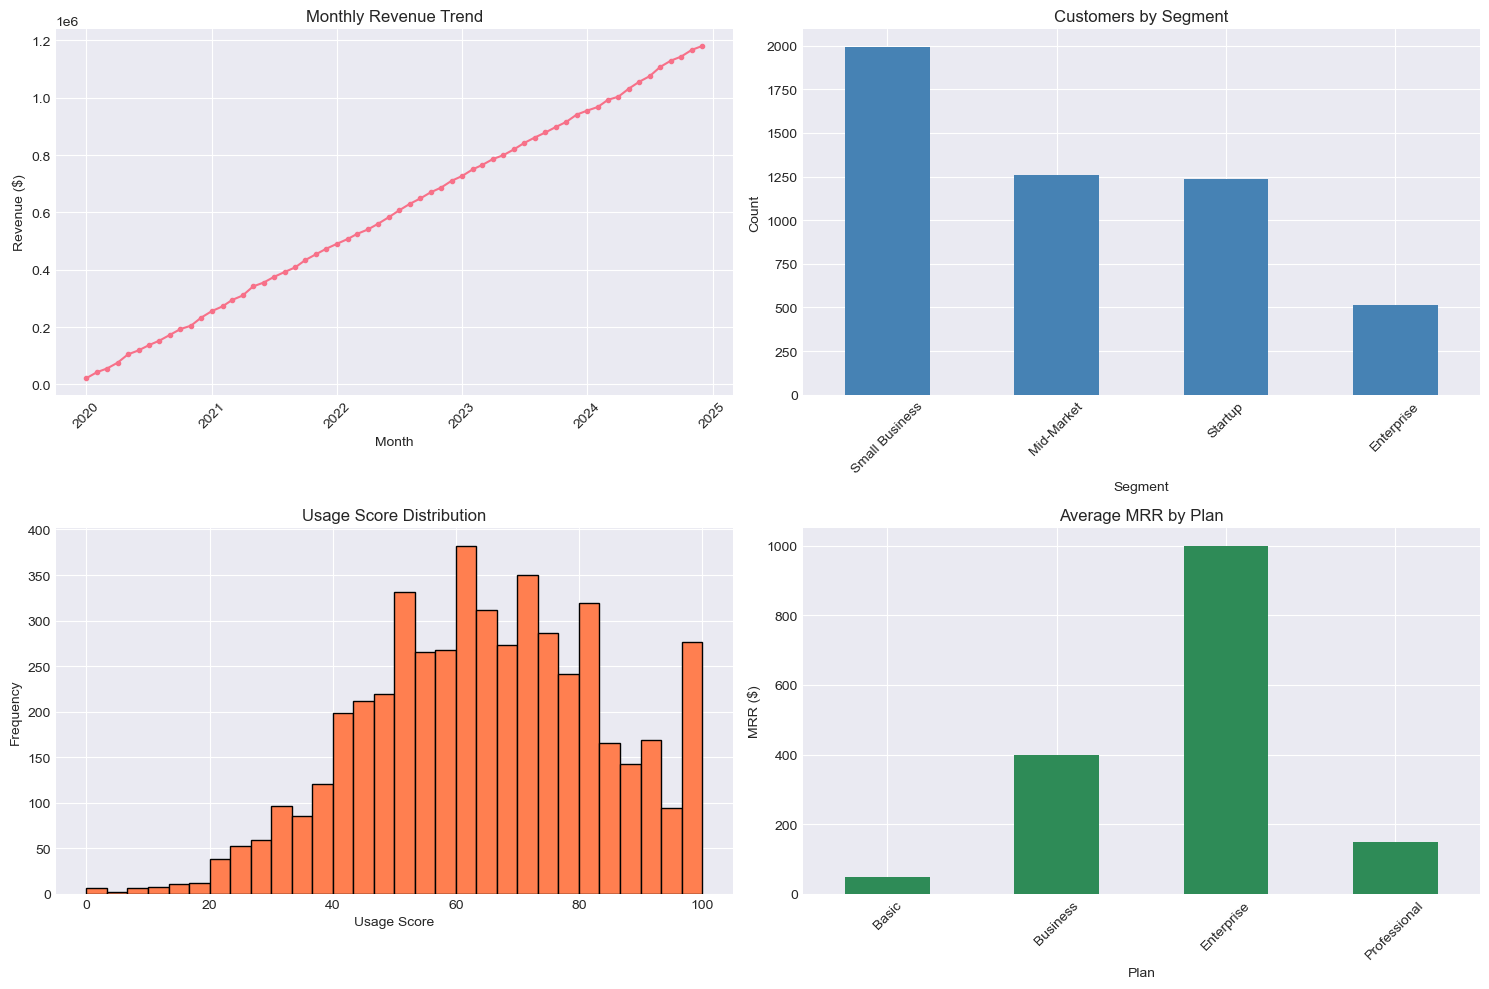

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: monthly revenue trend
axes[0,0].plot(pd.to_datetime(monthly_revenue['month']), monthly_revenue['amount'], marker='o', markersize=3)
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=45)

# Panel 2: customers per segment
customers_df['segment'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Customers by Segment')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# Panel 3: usage score distribution
axes[1,0].hist(customers_df['usage_score'], bins=30, color='coral', edgecolor='black')
axes[1,0].set_title('Usage Score Distribution')
axes[1,0].set_xlabel('Usage Score')
axes[1,0].set_ylabel('Frequency')

# Panel 4: MRR by plan
customers_df.groupby('plan')['mrr'].mean().plot(kind='bar', ax=axes[1,1], color='seagreen')
axes[1,1].set_title('Average MRR by Plan')
axes[1,1].set_xlabel('Plan')
axes[1,1].set_ylabel('MRR ($)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('financial_viz/01_initial_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Compare the most recent 6 months of revenue against the 6 months before that
recent_6mo = monthly_revenue['amount'].tail(6).sum()
prior_6mo = monthly_revenue['amount'].iloc[-12:-6].sum()

revenue_growth_rate = ((recent_6mo - prior_6mo) / prior_6mo) * 100

print(f"Prior 6 months revenue:  ${prior_6mo:,.2f}")
print(f"Recent 6 months revenue: ${recent_6mo:,.2f}")
print(f"Revenue Growth Rate (6mo): {revenue_growth_rate:+.2f}%")

Prior 6 months revenue:  $6,006,622.61
Recent 6 months revenue: $6,802,846.15
Revenue Growth Rate (6mo): +13.26%


In [12]:
revenue_series = monthly_revenue.set_index(pd.to_datetime(monthly_revenue['month']))['amount']
revenue_series.index.freq = 'MS'  # tell pandas this is monthly data, starting on the 1st of each month

print(revenue_series.head())
print(f"\nSeries length: {len(revenue_series)}")
print(f"Index type: {type(revenue_series.index)}")

month
2020-01-01     21878.65
2020-02-01     42934.00
2020-03-01     55509.00
2020-04-01     75856.80
2020-05-01    104698.22
Freq: MS, Name: amount, dtype: float64

Series length: 60
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


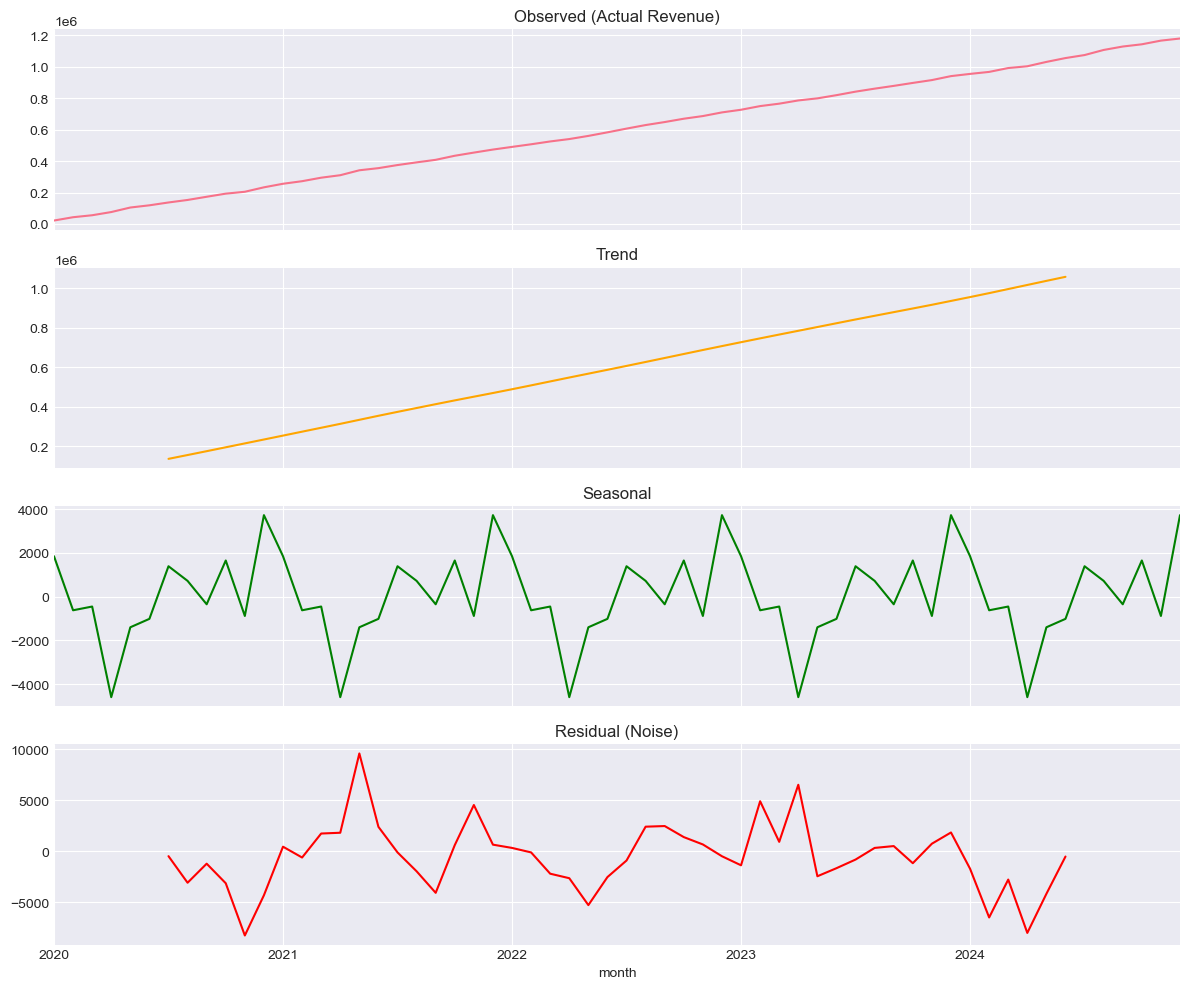

Decomposition complete.
Trend range: $135,867 to $1,057,483


In [13]:
decomposition = seasonal_decompose(revenue_series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed (Actual Revenue)')
decomposition.trend.plot(ax=axes[1], title='Trend', color='orange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)', color='red')
plt.tight_layout()
plt.savefig('financial_viz/02_ts_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print("Decomposition complete.")
print(f"Trend range: ${decomposition.trend.min():,.0f} to ${decomposition.trend.max():,.0f}")

In [14]:
result = adfuller(revenue_series)

print("Augmented Dickey-Fuller Test")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] <= 0.05:
    print("\n=> p-value <= 0.05: Series IS stationary")
else:
    print("\n=> p-value > 0.05: Series is NOT stationary (as expected, since revenue is growing)")

Augmented Dickey-Fuller Test
ADF Statistic: 0.9980
p-value: 0.9942
Critical Values:
   1%: -3.5553
   5%: -2.9157
   10%: -2.5957

=> p-value > 0.05: Series is NOT stationary (as expected, since revenue is growing)


After differencing — ADF p-value: 0.0001
=> Differenced series IS stationary. d=1 is enough.


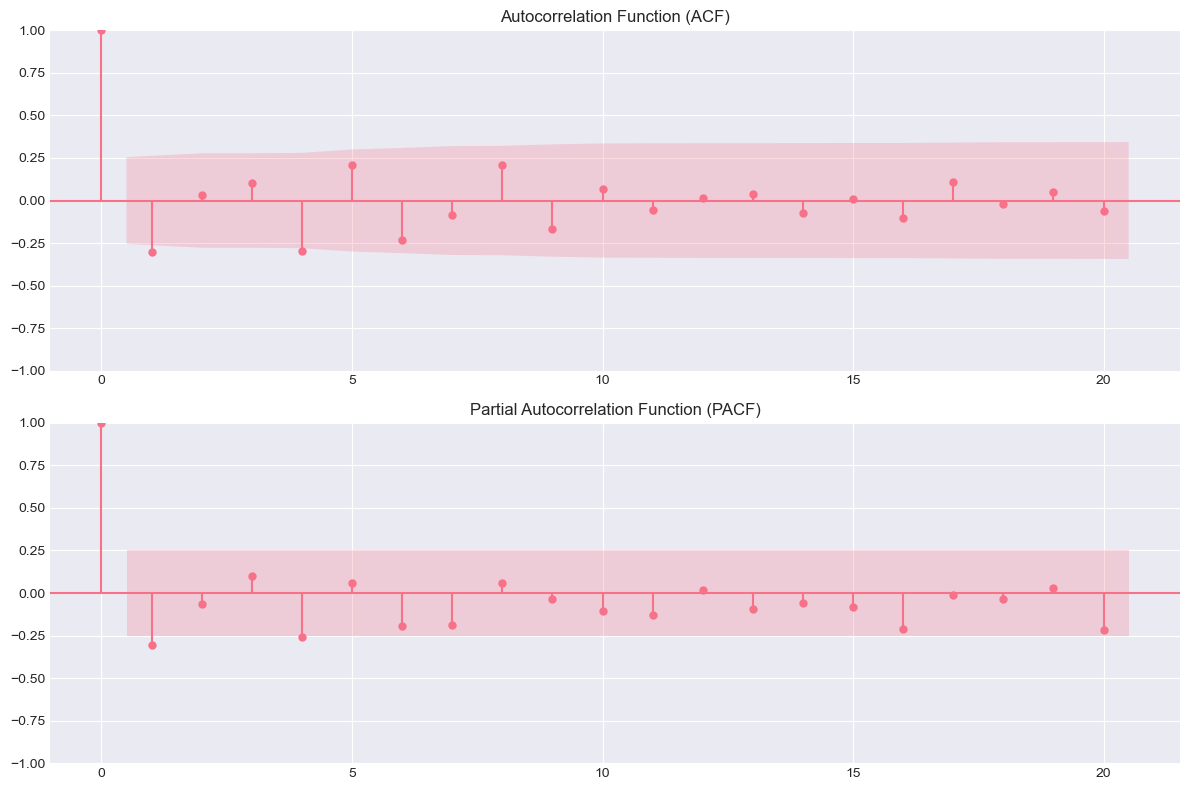

In [15]:
revenue_diff = revenue_series.diff().dropna()

# Re-check stationarity on the differenced series
result_diff = adfuller(revenue_diff)
print(f"After differencing — ADF p-value: {result_diff[1]:.4f}")
if result_diff[1] <= 0.05:
    print("=> Differenced series IS stationary. d=1 is enough.")
else:
    print("=> Still not stationary — would need a second differencing (d=2).")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(revenue_diff, ax=axes[0], lags=20)
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(revenue_diff, ax=axes[1], lags=20)
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.savefig('financial_viz/03_acf_pacf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
train_size = int(len(revenue_series) * 0.8)
train_data = revenue_series[:train_size]
test_data = revenue_series[train_size:]

print(f"Train size: {len(train_data)} months ({train_data.index[0].date()} to {train_data.index[-1].date()})")
print(f"Test size: {len(test_data)} months ({test_data.index[0].date()} to {test_data.index[-1].date()})")

model = ARIMA(train_data, order=(1, 1, 1))
fitted_model = model.fit()
print(fitted_model.summary())


Train size: 48 months (2020-01-01 to 2023-12-01)
Test size: 12 months (2024-01-01 to 2024-12-01)
                               SARIMAX Results                                
Dep. Variable:                 amount   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -460.291
Date:                Sat, 12 Sep 2026   AIC                            926.582
Time:                        15:40:34   BIC                            932.132
Sample:                    01-01-2020   HQIC                           928.670
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   7.05e-05   1.42e+04      0.000       1.000       1.000
ma.L1         -0.9974      0.197  

MAE:  $8,169.62
MAPE: 0.77%
Model Accuracy: 99.23%


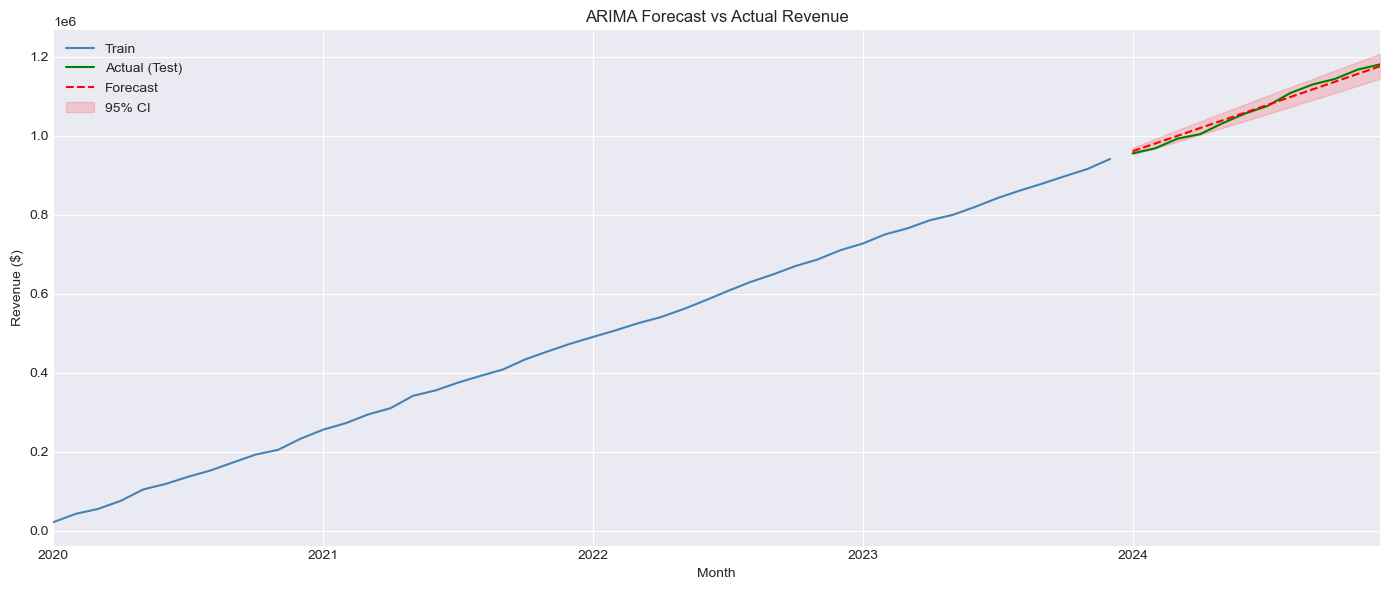

In [17]:
forecast_result = fitted_model.get_forecast(steps=len(test_data))
forecast_values = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

mae = np.mean(np.abs(test_data.values - forecast_values.values))
mape = np.mean(np.abs((test_data.values - forecast_values.values) / test_data.values)) * 100

print(f"MAE:  ${mae:,.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Model Accuracy: {100 - mape:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
train_data.plot(ax=ax, label='Train', color='steelblue')
test_data.plot(ax=ax, label='Actual (Test)', color='green')
forecast_values.plot(ax=ax, label='Forecast', color='red', linestyle='--')
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.15, label='95% CI')
ax.set_title('ARIMA Forecast vs Actual Revenue')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig('financial_viz/04_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
final_model = ARIMA(revenue_series, order=(1, 1, 1))
final_fitted = final_model.fit()

future_forecast = final_fitted.get_forecast(steps=12)
forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int(alpha=0.05)

print("Next 12 months forecast:")
print(forecast_mean)
print(f"\nTotal forecasted revenue (12mo): ${forecast_mean.sum():,.2f}")
print(f"Average monthly forecast: ${forecast_mean.mean():,.2f}")

Next 12 months forecast:
2025-01-01    1.200001e+06
2025-02-01    1.219627e+06
2025-03-01    1.239253e+06
2025-04-01    1.258879e+06
2025-05-01    1.278504e+06
2025-06-01    1.298130e+06
2025-07-01    1.317756e+06
2025-08-01    1.337382e+06
2025-09-01    1.357007e+06
2025-10-01    1.376633e+06
2025-11-01    1.396259e+06
2025-12-01    1.415885e+06
Freq: MS, Name: predicted_mean, dtype: float64

Total forecasted revenue (12mo): $15,695,315.57
Average monthly forecast: $1,307,942.96


In [19]:
!pip install prophet

In [20]:
from prophet import Prophet

# Prophet requires exactly two columns: 'ds' (date) and 'y' (value)
prophet_df = monthly_revenue.copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['month'])
prophet_df['y'] = prophet_df['amount']
prophet_df = prophet_df[['ds', 'y']]

print(prophet_df.head())

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=12, freq='MS')
prophet_forecast = m.predict(future)

print(f"\nProphet forecast (next 12 months):")
print(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))

prophet_12mo_total = prophet_forecast['yhat'].tail(12).sum()
print(f"\nProphet total forecasted revenue (12mo): ${prophet_12mo_total:,.2f}")

          ds          y
0 2020-01-01   21878.65
1 2020-02-01   42934.00
2 2020-03-01   55509.00
3 2020-04-01   75856.80
4 2020-05-01  104698.22


15:40:36 - cmdstanpy - INFO - Chain [1] start processing
15:40:37 - cmdstanpy - INFO - Chain [1] done processing



Prophet forecast (next 12 months):
           ds          yhat    yhat_lower    yhat_upper
60 2025-01-01  1.208209e+06  1.204932e+06  1.211683e+06
61 2025-02-01  1.226090e+06  1.222531e+06  1.229830e+06
62 2025-03-01  1.242631e+06  1.238877e+06  1.246401e+06
63 2025-04-01  1.260216e+06  1.255959e+06  1.264539e+06
64 2025-05-01  1.287036e+06  1.282097e+06  1.291937e+06
65 2025-06-01  1.307411e+06  1.302325e+06  1.312702e+06
66 2025-07-01  1.329247e+06  1.322836e+06  1.335365e+06
67 2025-08-01  1.352581e+06  1.345411e+06  1.360370e+06
68 2025-09-01  1.373404e+06  1.365330e+06  1.381677e+06
69 2025-10-01  1.394806e+06  1.385698e+06  1.404207e+06
70 2025-11-01  1.413727e+06  1.402542e+06  1.425190e+06
71 2025-12-01  1.436170e+06  1.423904e+06  1.449106e+06

Prophet total forecasted revenue (12mo): $15,831,528.53


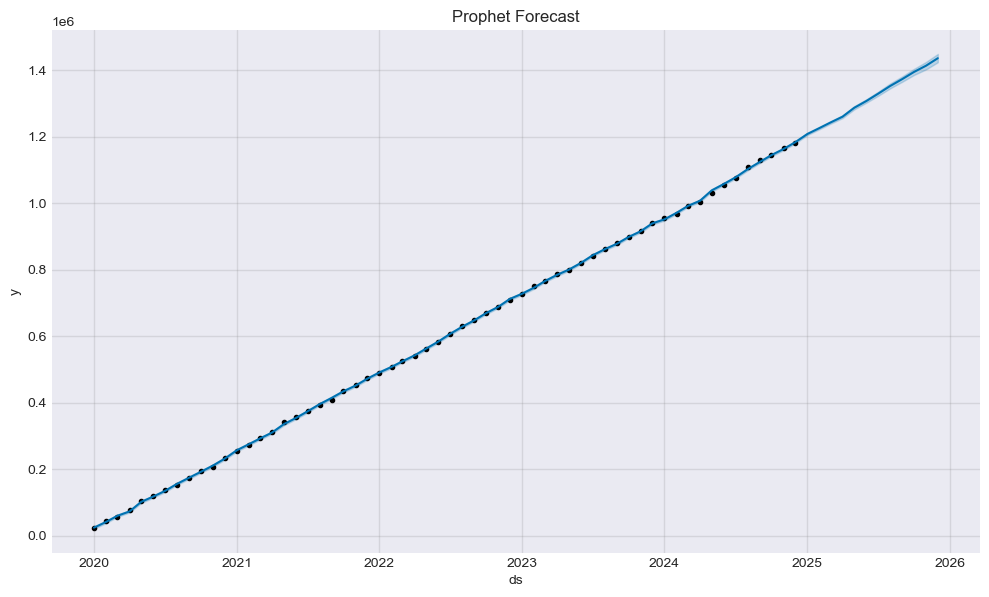

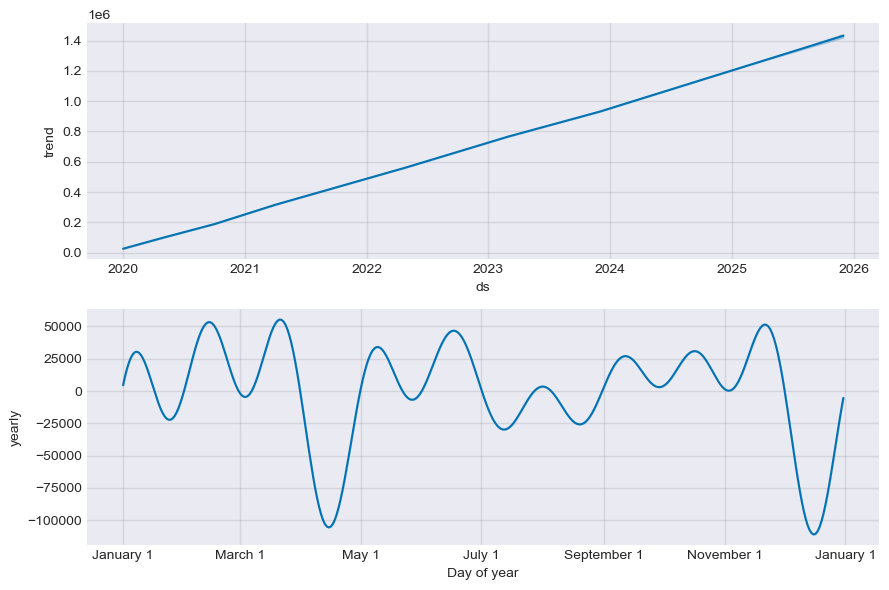

In [21]:
fig1 = m.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.savefig('financial_viz/05_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = m.plot_components(prophet_forecast)
plt.savefig('financial_viz/06_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Customer lifetime in months (from signup to churn, or to end of dataset if still active)
customers_df['lifetime_months'] = (
    (customers_df['churn_date'].fillna(end) - customers_df['signup_date']).dt.days / 30
).round(1)

# Total revenue per customer (sum of all their transactions)
customer_revenue = transactions_df.groupby('customer_id')['amount'].sum().reset_index()
customer_revenue.columns = ['customer_id', 'total_revenue']
customers_df = customers_df.merge(customer_revenue, on='customer_id', how='left')

# Customer Lifetime Value - simplified as total revenue collected so far
customers_df['clv'] = customers_df['total_revenue']

# Recency: days since their last transaction
last_transaction = transactions_df.groupby('customer_id')['transaction_date'].max().reset_index()
last_transaction.columns = ['customer_id', 'last_transaction_date']
customers_df = customers_df.merge(last_transaction, on='customer_id', how='left')
customers_df['recency_days'] = (end - customers_df['last_transaction_date']).dt.days

# Frequency: number of transactions
transaction_count = transactions_df.groupby('customer_id').size().reset_index()
transaction_count.columns = ['customer_id', 'transaction_count']
customers_df = customers_df.merge(transaction_count, on='customer_id', how='left')

# Monetary: average transaction value
avg_transaction = transactions_df.groupby('customer_id')['amount'].mean().reset_index()
avg_transaction.columns = ['customer_id', 'avg_transaction_value']
customers_df = customers_df.merge(avg_transaction, on='customer_id', how='left')

# From here on, use "customers" as the working alias (matches the original notebook's variable name)
customers = customers_df

print(customers[['customer_id','lifetime_months','total_revenue','clv','recency_days','transaction_count','avg_transaction_value']].head())
print(f"\nAverage CLV: ${customers['clv'].mean():,.2f}")
print(f"Average lifetime: {customers['lifetime_months'].mean():.1f} months")



















   customer_id  lifetime_months  total_revenue      clv  recency_days  \
0  CUST_000001             23.3        1194.63  1194.63             3   
1  CUST_000002             12.2         676.89   676.89             2   
2  CUST_000003             22.7        3470.20  3470.20           296   
3  CUST_000004             17.7        7107.69  7107.69            13   
4  CUST_000005             23.2        9839.84  9839.84            27   

   transaction_count  avg_transaction_value  
0                 24              49.776250  
1                 13              52.068462  
2                 23             150.878261  
3                 18             394.871667  
4                 23             427.819130  

Average CLV: $7,166.83
Average lifetime: 26.9 months


In [23]:
total_customers = len(customers)
churned_customers = customers['is_churned'].sum()
active_customers = total_customers - churned_customers
overall_churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers: {total_customers:,}")
print(f"Active Customers: {active_customers:,} ({active_customers/total_customers*100:.1f}%)")
print(f"Churned Customers: {churned_customers:,} ({overall_churn_rate:.1f}%)")

churned_lifetime = customers[customers['is_churned'] == 1]['lifetime_months']
active_lifetime = customers[customers['is_churned'] == 0]['lifetime_months']
print(f"\nAvg lifetime — Churned customers: {churned_lifetime.mean():.1f} months")
print(f"Avg lifetime — Active customers:  {active_lifetime.mean():.1f} months")

# Churn rate by plan and by contract length
print("\nChurn rate by plan:")
print(customers.groupby('plan')['is_churned'].mean().round(3))

print("\nChurn rate by contract length:")
print(customers.groupby('contract_length')['is_churned'].mean().round(3))

Total Customers: 5,000
Active Customers: 4,344.0 (86.9%)
Churned Customers: 656.0 (13.1%)

Avg lifetime — Churned customers: 13.0 months
Avg lifetime — Active customers:  29.0 months

Churn rate by plan:
plan
Basic           0.148
Business        0.123
Enterprise      0.128
Professional    0.118
Name: is_churned, dtype: float64

Churn rate by contract length:
contract_length
1     0.139
12    0.134
24    0.119
36    0.125
Name: is_churned, dtype: float64


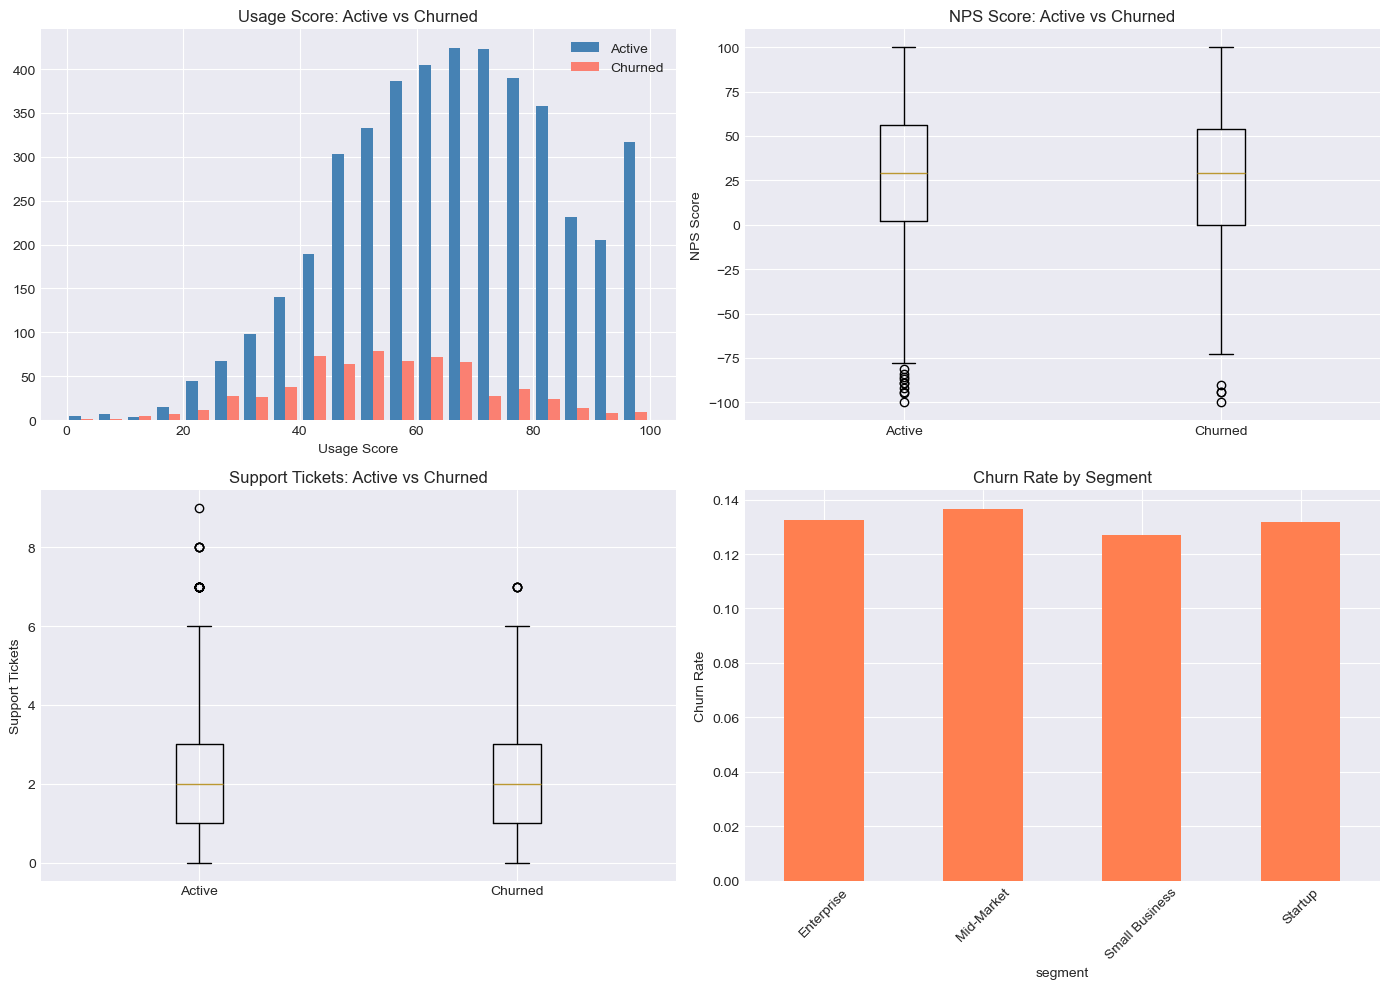

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: usage score, churned vs active
churned = customers[customers['is_churned'] == 1]['usage_score']
active = customers[customers['is_churned'] == 0]['usage_score']
axes[0,0].hist([active, churned], bins=20, label=['Active', 'Churned'], color=['steelblue', 'salmon'])
axes[0,0].set_title('Usage Score: Active vs Churned')
axes[0,0].set_xlabel('Usage Score')
axes[0,0].legend()

# Panel 2: NPS score, churned vs active
axes[0,1].boxplot([customers[customers['is_churned']==0]['nps_score'],
                    customers[customers['is_churned']==1]['nps_score']],
                   labels=['Active', 'Churned'])
axes[0,1].set_title('NPS Score: Active vs Churned')
axes[0,1].set_ylabel('NPS Score')

# Panel 3: support tickets, churned vs active
axes[1,0].boxplot([customers[customers['is_churned']==0]['support_tickets'],
                    customers[customers['is_churned']==1]['support_tickets']],
                   labels=['Active', 'Churned'])
axes[1,0].set_title('Support Tickets: Active vs Churned')
axes[1,0].set_ylabel('Support Tickets')

# Panel 4: churn rate by segment
customers.groupby('segment')['is_churned'].mean().plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Churn Rate by Segment')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('financial_viz/07_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
churn_model_data = customers.copy()

churn_model_data['customer_age_days'] = (
    pd.to_datetime('2024-12-31') - churn_model_data['signup_date']
).dt.days

churn_model_data['avg_revenue_per_month'] = (
    churn_model_data['total_revenue'] / churn_model_data['lifetime_months']
)
churn_model_data['tickets_per_month'] = (
    churn_model_data['support_tickets'] / churn_model_data['lifetime_months']
)

churn_model_data['low_usage'] = (churn_model_data['usage_score'] < 40).astype(int)
churn_model_data['low_nps'] = (churn_model_data['nps_score'] < 0).astype(int)
churn_model_data['short_contract'] = (churn_model_data['contract_length'] <= 1).astype(int)

feature_columns = [
    'mrr', 'contract_length', 'number_of_users', 'support_tickets',
    'usage_score', 'nps_score', 'customer_age_days', 'lifetime_months',
    'transaction_count', 'avg_transaction_value', 'recency_days',
    'tickets_per_month', 'low_usage', 'low_nps', 'short_contract'
]
categorical_features = ['segment', 'industry', 'plan', 'country']

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    churn_model_data[f'{col}_encoded'] = le.fit_transform(churn_model_data[col].astype(str))
    label_encoders[col] = le
    feature_columns.append(f'{col}_encoded')

X = churn_model_data[feature_columns].fillna(0)
y = churn_model_data['is_churned']

print(f"Total features: {X.shape[1]}")
print(f"Samples: {len(X):,}  |  Churned: {y.sum():,.0f} ({y.mean()*100:.1f}%)  |  Active: {(1-y).sum():,.0f}")
print(f"\nFeature list: {feature_columns}")

Total features: 19
Samples: 5,000  |  Churned: 656 (13.1%)  |  Active: 4,344

Feature list: ['mrr', 'contract_length', 'number_of_users', 'support_tickets', 'usage_score', 'nps_score', 'customer_age_days', 'lifetime_months', 'transaction_count', 'avg_transaction_value', 'recency_days', 'tickets_per_month', 'low_usage', 'low_nps', 'short_contract', 'segment_encoded', 'industry_encoded', 'plan_encoded', 'country_encoded']


In [27]:
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Any infinite values remaining: {np.isinf(X.values).any()}")
print(f"Any NaN values remaining: {X.isnull().values.any()}")

Any infinite values remaining: False
Any NaN values remaining: False


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} samples ({y_train.mean()*100:.1f}% churned)")
print(f"Test:  {len(X_test):,} samples ({y_test.mean()*100:.1f}% churned)")

# Scale features for Logistic Regression (it's sensitive to feature scale; trees are not)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {}

# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = log_reg

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model

# Model 3: Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
models['Gradient Boosting'] = gb_model

print("\nAll 3 models trained successfully!")

Train: 4,000 samples (13.1% churned)
Test:  1,000 samples (13.1% churned)

All 3 models trained successfully!


In [29]:
results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

print(f"{'Model':<22}{'Accuracy':<10}{'Precision':<11}{'Recall':<9}{'F1':<8}{'ROC AUC':<8}")
print("-" * 68)
for name, r in results.items():
    print(f"{name:<22}{r['accuracy']:<10.3f}{r['precision']:<11.3f}{r['recall']:<9.3f}{r['f1']:<8.3f}{r['roc_auc']:<8.3f}")

best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\nBest model by ROC AUC: {best_model_name} ({results[best_model_name]['roc_auc']:.3f})")

Model                 Accuracy  Precision  Recall   F1      ROC AUC 
--------------------------------------------------------------------
Logistic Regression   0.998     0.992      0.992    0.992   0.995   
Random Forest         1.000     1.000      1.000    1.000   1.000   
Gradient Boosting     1.000     1.000      1.000    1.000   1.000   

Best model by ROC AUC: Random Forest (1.000)


In [30]:
importances = pd.DataFrame({
    'feature': feature_columns,
    'importance': models['Random Forest'].feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(10))

                  feature  importance
10           recency_days    0.522819
7         lifetime_months    0.155873
6       customer_age_days    0.119632
8       transaction_count    0.117858
11      tickets_per_month    0.034260
4             usage_score    0.022254
9   avg_transaction_value    0.005482
3         support_tickets    0.004553
2         number_of_users    0.003961
5               nps_score    0.003406


In [31]:
clean_feature_columns = [
    'mrr', 'contract_length', 'number_of_users', 'support_tickets',
    'usage_score', 'nps_score', 'customer_age_days',
    'avg_transaction_value', 'low_usage', 'low_nps', 'short_contract',
    'segment_encoded', 'industry_encoded', 'plan_encoded', 'country_encoded'
]

X_clean = churn_model_data[clean_feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
y_clean = churn_model_data['is_churned']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

models_clean = {}
log_reg2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg2.fit(X_train2_scaled, y_train2)
models_clean['Logistic Regression'] = log_reg2

rf_model2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model2.fit(X_train2, y_train2)
models_clean['Random Forest'] = rf_model2

gb_model2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model2.fit(X_train2, y_train2)
models_clean['Gradient Boosting'] = gb_model2

results_clean = {}
for name, model in models_clean.items():
    Xte = X_test2_scaled if name == 'Logistic Regression' else X_test2
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    results_clean[name] = {
        'accuracy': accuracy_score(y_test2, y_pred),
        'precision': precision_score(y_test2, y_pred),
        'recall': recall_score(y_test2, y_pred),
        'f1': f1_score(y_test2, y_pred),
        'roc_auc': roc_auc_score(y_test2, y_prob),
    }

print(f"{'Model':<22}{'Accuracy':<10}{'Precision':<11}{'Recall':<9}{'F1':<8}{'ROC AUC':<8}")
print("-" * 68)
for name, r in results_clean.items():
    print(f"{name:<22}{r['accuracy']:<10.3f}{r['precision']:<11.3f}{r['recall']:<9.3f}{r['f1']:<8.3f}{r['roc_auc']:<8.3f}")

Model                 Accuracy  Precision  Recall   F1      ROC AUC 
--------------------------------------------------------------------
Logistic Regression   0.626     0.214      0.695    0.327   0.706   
Random Forest         0.872     1.000      0.023    0.045   0.696   
Gradient Boosting     0.873     0.700      0.053    0.099   0.756   


Best model by ROC AUC: Gradient Boosting (0.756)


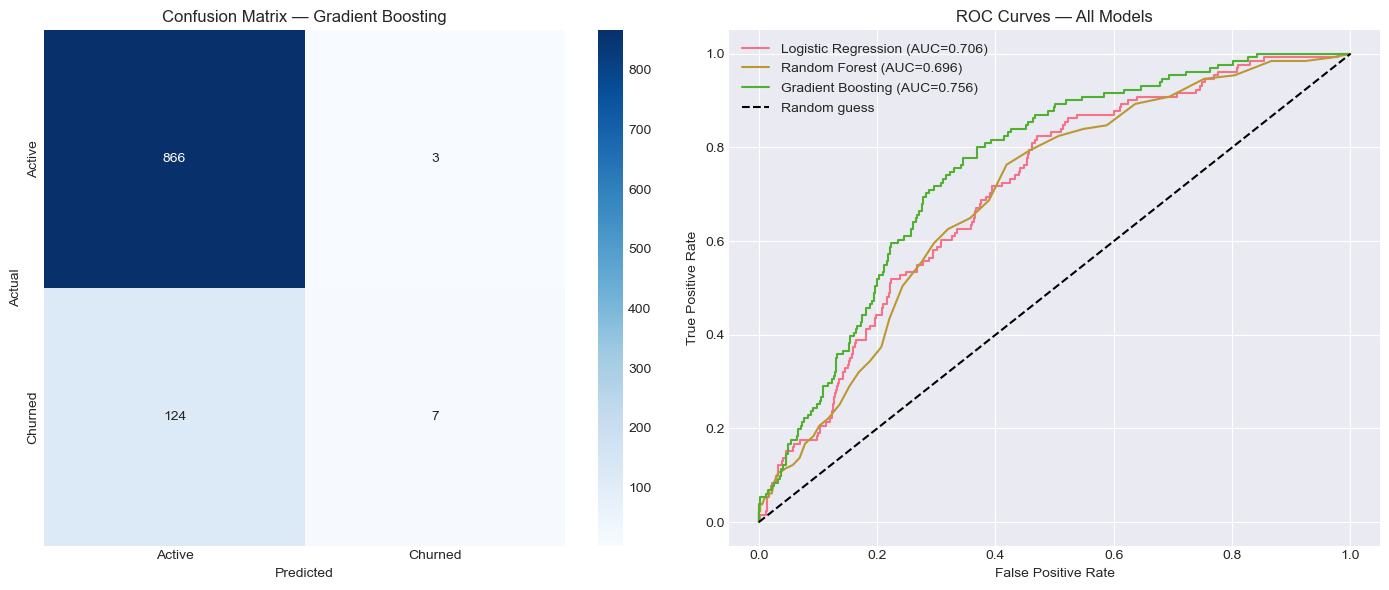

In [32]:
best_model_name = max(results_clean, key=lambda k: results_clean[k]['roc_auc'])
best_model = models_clean[best_model_name]
print(f"Best model by ROC AUC: {best_model_name} ({results_clean[best_model_name]['roc_auc']:.3f})")

Xte_best = X_test2_scaled if best_model_name == 'Logistic Regression' else X_test2
y_pred_best = best_model.predict(Xte_best)
y_prob_best = best_model.predict_proba(Xte_best)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test2, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
axes[0].set_title(f'Confusion Matrix — {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

for name, model in models_clean.items():
    Xte = X_test2_scaled if name == 'Logistic Regression' else X_test2
    y_prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test2, y_prob)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={results_clean[name]['roc_auc']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend()

plt.tight_layout()
plt.savefig('financial_viz/08_churn_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# Instead of the default 0.5 cutoff, try a lower threshold — better suited to a rare, costly-to-miss event
for threshold in [0.5, 0.3, 0.2, 0.15]:
    y_pred_thresh = (y_prob_best >= threshold).astype(int)
    prec = precision_score(y_test2, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test2, y_pred_thresh, zero_division=0)
    print(f"Threshold {threshold:<5} → Precision: {prec:.3f}  Recall: {rec:.3f}  "
          f"Flagged as at-risk: {y_pred_thresh.sum()}")

Threshold 0.5   → Precision: 0.700  Recall: 0.053  Flagged as at-risk: 10
Threshold 0.3   → Precision: 0.295  Recall: 0.176  Flagged as at-risk: 78
Threshold 0.2   → Precision: 0.271  Recall: 0.443  Flagged as at-risk: 214
Threshold 0.15  → Precision: 0.262  Recall: 0.733  Flagged as at-risk: 366


In [34]:
churn_model_data['churn_probability'] = best_model.predict_proba(
    X_clean if best_model_name != 'Logistic Regression' else scaler2.transform(X_clean)
)[:, 1]

churn_model_data['churn_risk_tier'] = pd.cut(
    churn_model_data['churn_probability'],
    bins=[0, 0.15, 0.30, 0.50, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("Customers by risk tier:")
print(churn_model_data['churn_risk_tier'].value_counts())

at_risk = churn_model_data[
    (churn_model_data['is_churned'] == 0) &          # only currently-active customers matter for retention action
    (churn_model_data['churn_probability'] > 0.15)
].sort_values('churn_probability', ascending=False)

at_risk_output = at_risk[[
    'customer_id', 'segment', 'plan', 'mrr', 'usage_score', 'nps_score',
    'support_tickets', 'churn_probability', 'churn_risk_tier'
]]

print(f"\nActive customers flagged as at-risk: {len(at_risk_output):,}")
print(f"Total at-risk MRR: ${at_risk_output['mrr'].sum():,.2f}/month")
print(f"Annualized at-risk revenue: ${at_risk_output['mrr'].sum() * 12:,.2f}/year")

at_risk_output.to_csv('at_risk_customers.csv', index=False)
print("\nSaved: at_risk_customers.csv")

Customers by risk tier:
churn_risk_tier
Low         3302
Medium      1294
High         327
Critical      77
Name: count, dtype: int64

Active customers flagged as at-risk: 1,166
Total at-risk MRR: $293,484.00/month
Annualized at-risk revenue: $3,521,808.00/year

Saved: at_risk_customers.csv


In [36]:
cohort_data = transactions.copy()
cohort_data['cohort_month'] = cohort_data['cohort_month'].astype(str)
cohort_data['transaction_month'] = cohort_data['transaction_month'].astype(str)

# How many months after signup did this transaction happen?
cohort_data['cohort_index'] = (
    pd.to_datetime(cohort_data['transaction_month']) -
    pd.to_datetime(cohort_data['cohort_month'])
).dt.days // 30

# Count unique customers still transacting, per cohort, per month-since-signup
cohort_counts = cohort_data.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_counts.columns = ['cohort_month', 'cohort_index', 'customer_count']

# Reshape: one row per cohort, one column per "months since signup"
retention_matrix = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_count')

# Convert counts to percentages of each cohort's original size
cohort_size = retention_matrix.iloc[:, 0]
retention_pct = retention_matrix.divide(cohort_size, axis=0) * 100

print("Cohort Retention Matrix (%) — first 12 cohorts, 13 months:\n")
print(retention_pct.iloc[:12, :13].round(1))

Cohort Retention Matrix (%) — first 12 cohorts, 13 months:

cohort_index     0      1      2      3      4      5      6      7     8   \
cohort_month                                                                 
2020-01       100.0  100.0  100.0  100.0   99.0   99.0   96.9   96.9  96.9   
2020-02       100.0    NaN  100.0  100.0   96.1   94.7   94.7   93.4  93.4   
2020-03       100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  97.0   
2020-04       100.0  100.0  100.0  100.0   98.7   98.7   97.3   96.0  93.3   
2020-05       100.0  100.0  100.0  100.0  100.0  100.0   97.9   97.9  97.9   
2020-06       100.0  100.0  100.0  100.0  100.0   98.6   95.9   95.9  95.9   
2020-07       100.0  100.0  100.0  100.0   98.8   97.6   95.2   94.0  94.0   
2020-08       100.0  100.0  100.0  100.0  100.0   98.8   97.5   96.2  96.2   
2020-09       100.0  100.0  100.0  100.0   98.7   97.4   96.1   96.1  96.1   
2020-10       100.0  100.0  100.0  100.0  100.0   97.2   95.8   94.4  90.3   
2020

In [37]:
customers['cohort_month'] = customers['signup_date'].dt.to_period('M')

transactions = transactions_df.merge(
    customers[['customer_id', 'cohort_month']], on='customer_id', how='left'
)
transactions['transaction_month'] = transactions['transaction_date'].dt.to_period('M')

print(transactions[['customer_id', 'transaction_date', 'transaction_month', 'cohort_month']].head())

   customer_id transaction_date transaction_month cohort_month
0  CUST_000001       2023-01-31           2023-01      2023-01
1  CUST_000001       2023-02-28           2023-02      2023-01
2  CUST_000001       2023-03-28           2023-03      2023-01
3  CUST_000001       2023-04-28           2023-04      2023-01
4  CUST_000001       2023-05-28           2023-05      2023-01


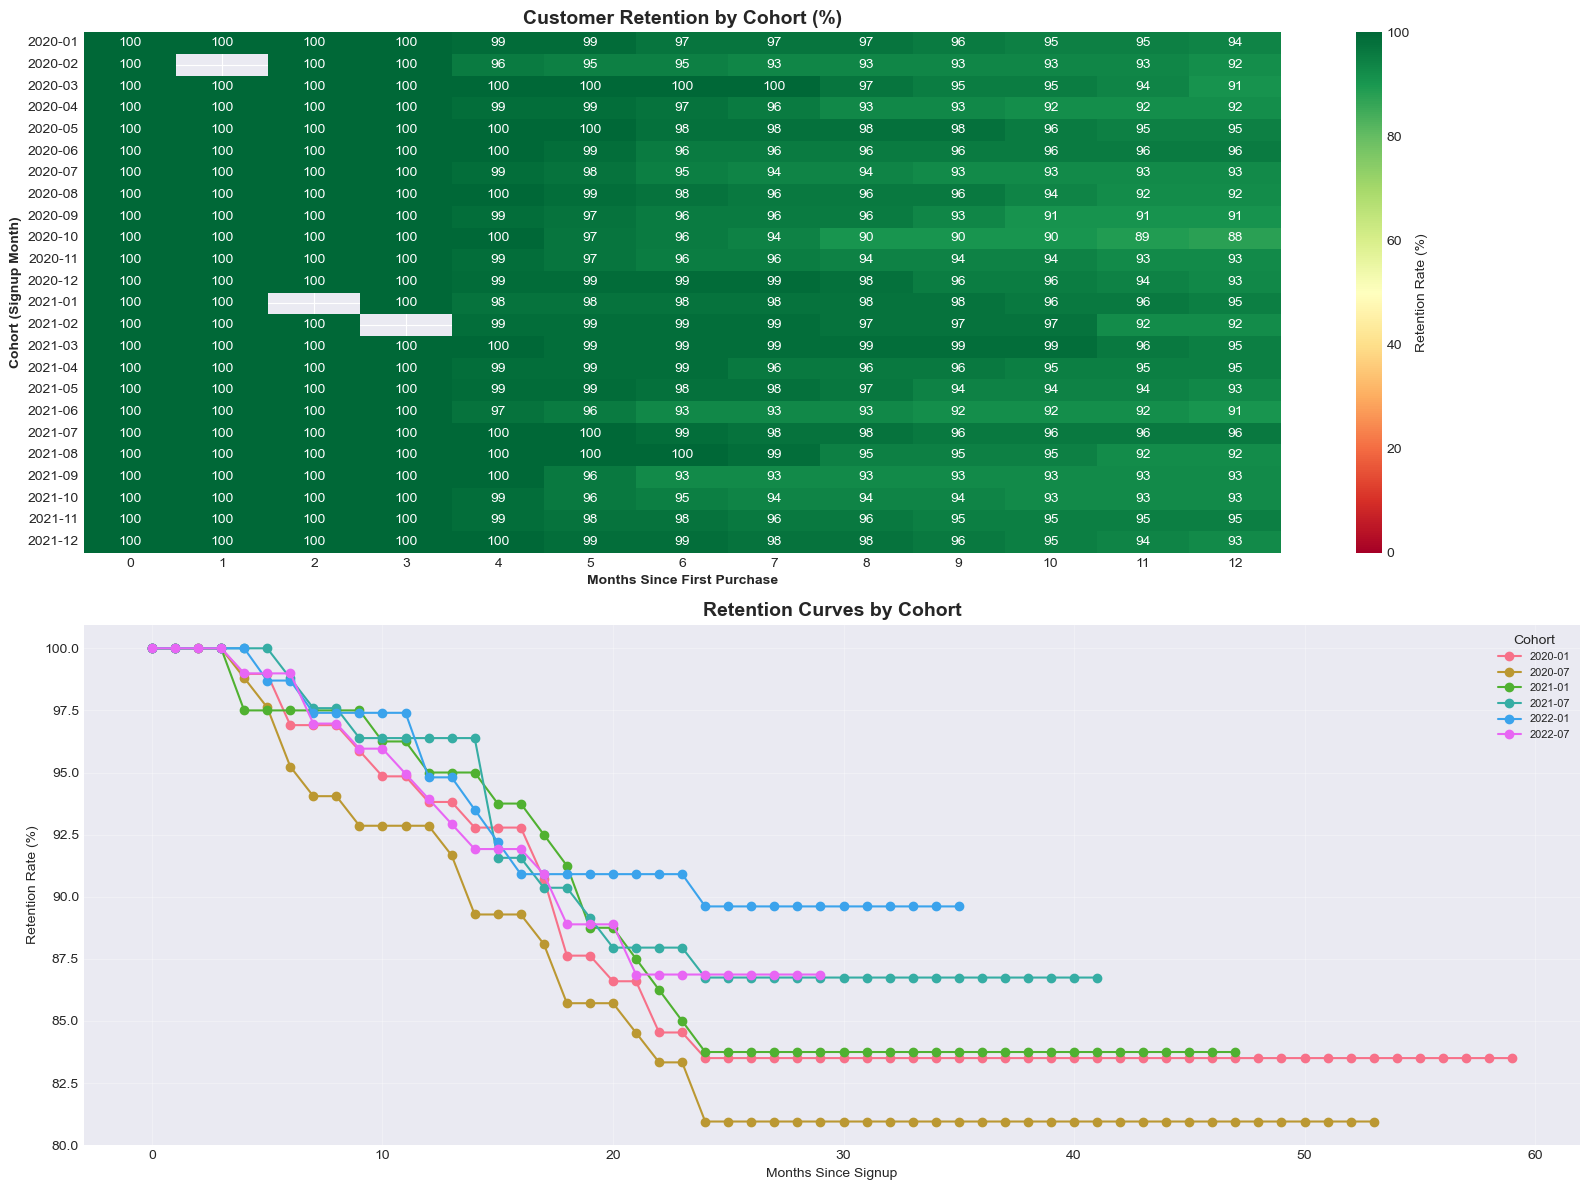

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Heatmap: darker green = higher retention
ax1 = axes[0]
sns.heatmap(retention_pct.iloc[:24, :13], annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax1, cbar_kws={'label': 'Retention Rate (%)'}, vmin=0, vmax=100)
ax1.set_title('Customer Retention by Cohort (%)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Months Since First Purchase', fontweight='bold')
ax1.set_ylabel('Cohort (Signup Month)', fontweight='bold')

# Line chart: retention curves for a sample of cohorts
ax2 = axes[1]
cohorts_to_plot = retention_pct.index[::6][:6]  # every 6th cohort, up to 6 lines
for cohort in cohorts_to_plot:
    cohort_curve = retention_pct.loc[cohort].dropna()
    ax2.plot(cohort_curve.index, cohort_curve.values, marker='o', label=str(cohort))
ax2.set_title('Retention Curves by Cohort', fontweight='bold', fontsize=14)
ax2.set_xlabel('Months Since Signup')
ax2.set_ylabel('Retention Rate (%)')
ax2.legend(title='Cohort', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('financial_viz/11_cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

Average Revenue per Customer by Cohort Month (first 12 cohorts, 7 months):

cohort_index       0       1       2       3       4       5       6
cohort_month                                                        
2020-01       225.55  230.53  225.75  225.45  227.76  228.31  232.87
2020-02       538.47     NaN  269.43  270.29  258.25  248.82  251.18
2020-03       200.92  200.87  201.40  201.16  203.24  199.77  197.73
2020-04       270.05  262.50  252.79  258.81  258.96  257.26  250.00
2020-05       305.33  304.13  308.78  303.70  313.24  313.69  301.59
2020-06       226.27  220.58  223.79  223.39  223.69  217.57  226.24
2020-07       219.18  224.96  225.76  224.59  218.79  234.08  231.63
2020-08       199.67  208.51  202.14  203.67  204.51  200.11  202.08
2020-09       251.44  259.10  252.98  261.37  269.71  258.06  264.81
2020-10       282.15  278.48  270.14  275.17  271.11  271.30  277.66
2020-11       258.62  263.60  261.24  266.47  264.61  252.54  255.73
2020-12       292.95  285.9

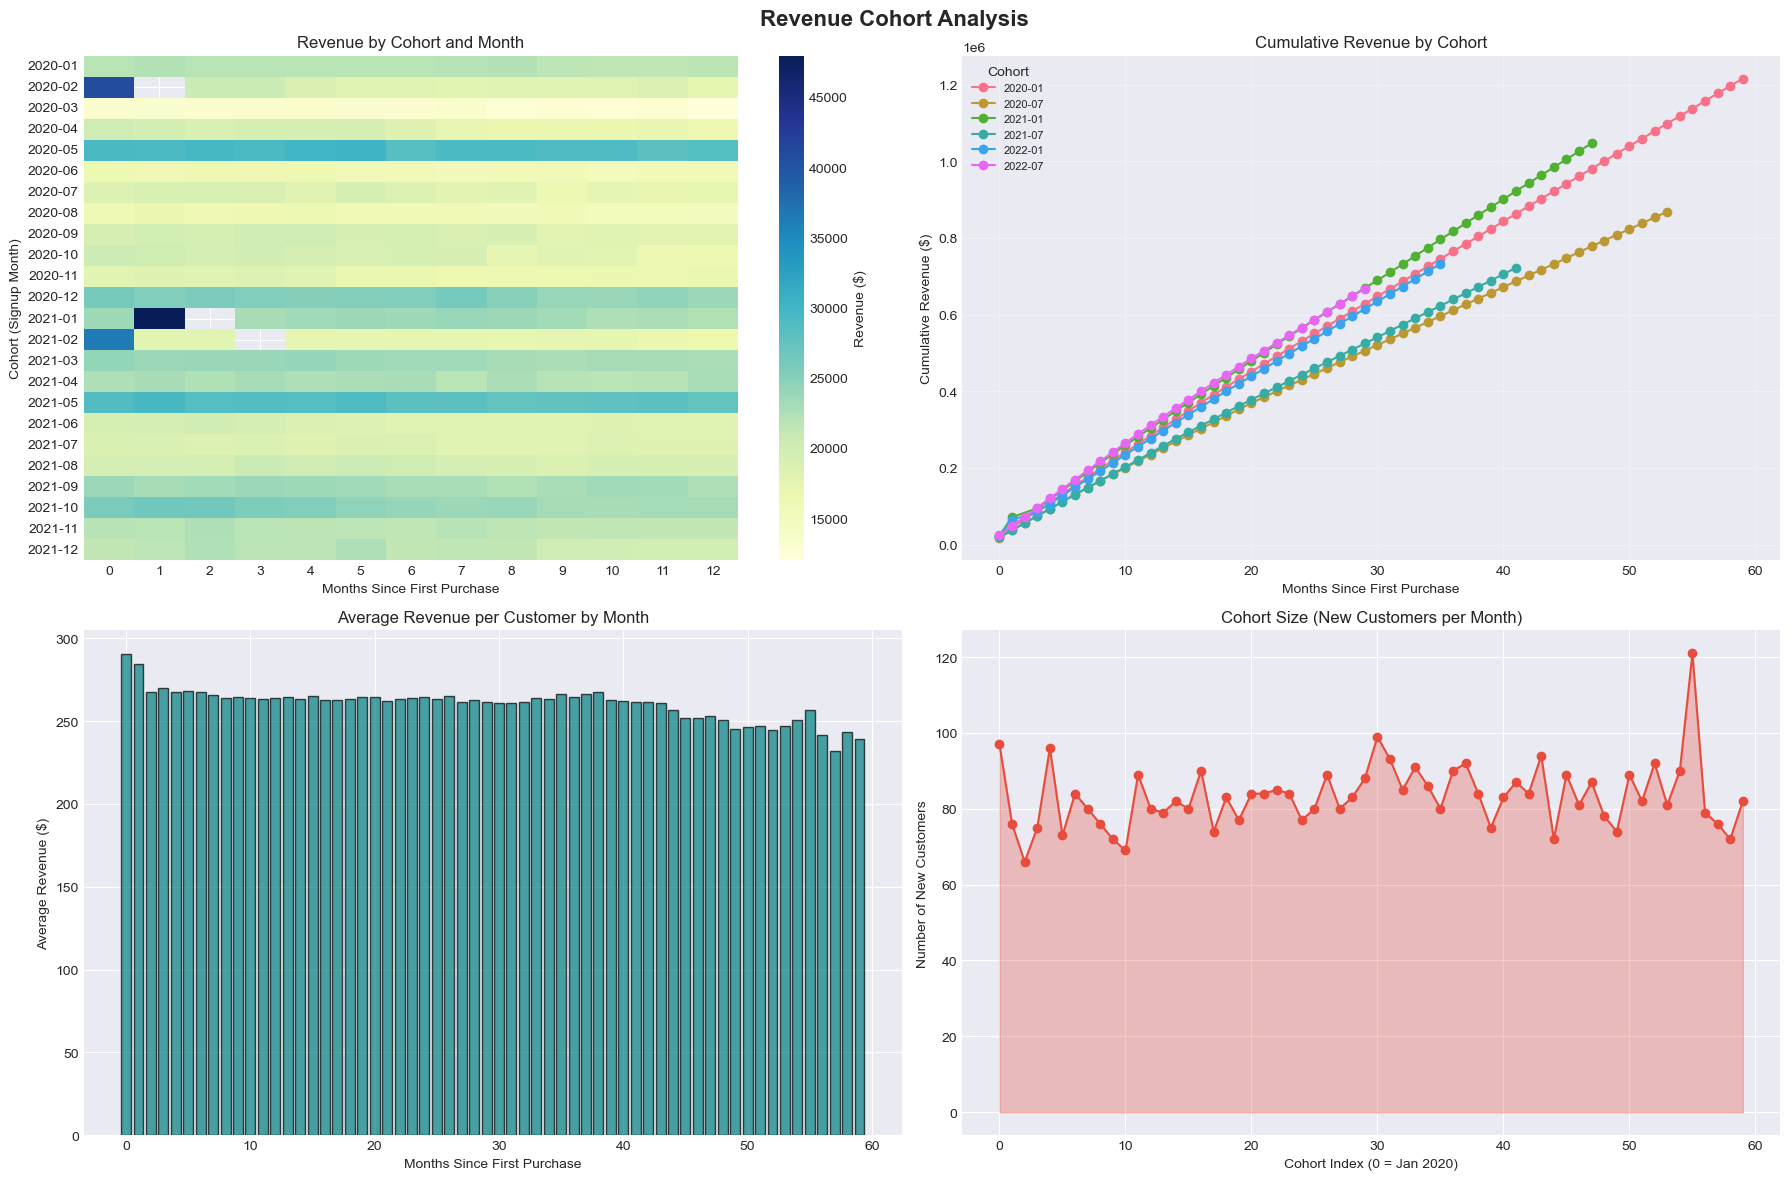

In [39]:
cohort_revenue = cohort_data.groupby(['cohort_month', 'cohort_index'])['amount'].sum().reset_index()
revenue_matrix = cohort_revenue.pivot(index='cohort_month', columns='cohort_index', values='amount')

avg_revenue_per_customer = revenue_matrix.divide(retention_matrix)
cumulative_revenue = revenue_matrix.cumsum(axis=1)

print("Average Revenue per Customer by Cohort Month (first 12 cohorts, 7 months):\n")
print(avg_revenue_per_customer.iloc[:12, :7].round(2))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax1 = axes[0, 0]
sns.heatmap(revenue_matrix.iloc[:24, :13], annot=False, cmap='YlGnBu', ax=ax1, cbar_kws={'label': 'Revenue ($)'})
ax1.set_title('Revenue by Cohort and Month')
ax1.set_xlabel('Months Since First Purchase')
ax1.set_ylabel('Cohort (Signup Month)')

ax2 = axes[0, 1]
cohorts_to_plot = retention_pct.index[::6][:6]
for cohort in cohorts_to_plot:
    if cohort in cumulative_revenue.index:
        cohort_cumrev = cumulative_revenue.loc[cohort].dropna()
        ax2.plot(cohort_cumrev.index, cohort_cumrev.values, marker='o', label=str(cohort))
ax2.set_title('Cumulative Revenue by Cohort')
ax2.set_xlabel('Months Since First Purchase')
ax2.set_ylabel('Cumulative Revenue ($)')
ax2.legend(title='Cohort', fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
avg_rev_by_month = avg_revenue_per_customer.mean(axis=0).dropna()
ax3.bar(avg_rev_by_month.index, avg_rev_by_month.values, color='teal', alpha=0.7, edgecolor='black')
ax3.set_title('Average Revenue per Customer by Month')
ax3.set_xlabel('Months Since First Purchase')
ax3.set_ylabel('Average Revenue ($)')

ax4 = axes[1, 1]
cohort_sizes = retention_matrix.iloc[:, 0].sort_index()
ax4.plot(range(len(cohort_sizes)), cohort_sizes.values, marker='o', color='#e74c3c')
ax4.fill_between(range(len(cohort_sizes)), cohort_sizes.values, alpha=0.3, color='#e74c3c')
ax4.set_title('Cohort Size (New Customers per Month)')
ax4.set_xlabel('Cohort Index (0 = Jan 2020)')
ax4.set_ylabel('Number of New Customers')

plt.suptitle('Revenue Cohort Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('financial_viz/12_revenue_cohorts.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
reference_date = pd.to_datetime('2024-12-31')

rfm_data = customers[customers['is_churned'] == 0].copy()  # only active customers

rfm_data['recency'] = rfm_data['recency_days']
rfm_data['frequency'] = rfm_data['transaction_count']
rfm_data['monetary'] = rfm_data['total_revenue']

# Score each dimension 1-5 using quintiles (5 equal-sized buckets)
rfm_data['r_score'] = pd.qcut(rfm_data['recency'], q=5, labels=[5, 4, 3, 2, 1])  # lower recency = better = higher score
rfm_data['f_score'] = pd.qcut(rfm_data['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_data['m_score'] = pd.qcut(rfm_data['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

rfm_data['r_score'] = rfm_data['r_score'].astype(int)
rfm_data['f_score'] = rfm_data['f_score'].astype(int)
rfm_data['m_score'] = rfm_data['m_score'].astype(int)

rfm_data['rfm_score'] = (
    rfm_data['r_score'].astype(str) + rfm_data['f_score'].astype(str) + rfm_data['m_score'].astype(str)
)

print(rfm_data[['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score']].head(10))

    customer_id  recency  frequency  monetary  r_score  f_score  m_score  \
0   CUST_000001        3         24   1194.63        5        3        2   
1   CUST_000002        2         13    676.89        5        2        1   
3   CUST_000004       13         18   7107.69        3        2        4   
4   CUST_000005       27         23   9839.84        1        2        4   
5   CUST_000006        3         25   1249.22        5        3        2   
6   CUST_000007       11          4    625.35        4        1        1   
7   CUST_000008       21         26  10379.77        2        3        4   
8   CUST_000009        5          7   1103.88        5        1        1   
9   CUST_000010       30         56   2793.27        1        5        3   
10  CUST_000011       20         45  18276.74        2        4        5   

   rfm_score  
0        532  
1        521  
3        324  
4        124  
5        532  
6        411  
7        234  
8        511  
9        153  
10       245 

In [41]:
def segment_customer(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating High Value'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r >= 3 and m <= 2:
        return 'Promising'
    else:
        return 'Need Attention'

rfm_data['customer_segment'] = rfm_data.apply(segment_customer, axis=1)

rfm_summary = rfm_data.groupby('customer_segment').agg({
    'customer_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum'],
    'mrr': 'sum'
})
rfm_summary.columns = ['Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue', 'Total_MRR']
rfm_summary = rfm_summary.sort_values('Total_Revenue', ascending=False)

print(rfm_summary.round(2))

rfm_export = rfm_data[['customer_id', 'segment', 'plan', 'recency', 'frequency',
                        'monetary', 'r_score', 'f_score', 'm_score', 'customer_segment']]
rfm_export.to_csv('rfm_segmentation.csv', index=False)
print("\nSaved: rfm_segmentation.csv")

                        Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
customer_segment                                                          
At Risk                   730        25.29          43.08      14179.07   
Loyal Customers           780        11.98          40.36      11189.45   
Champions                 470         6.44          46.93      17268.76   
New Customers             707         6.10          11.10       2878.97   
Hibernating High Value    246        24.91          14.24       7127.38   
Need Attention            374        21.89          27.99       3738.01   
Promising                 632        12.18          25.12       1436.98   
Lost                      405        24.85           9.32        887.94   

                        Total_Revenue  Total_MRR  
customer_segment                                  
At Risk                   10350720.32     245920  
Loyal Customers            8727770.31     231770  
Champions                  8116319.33     171

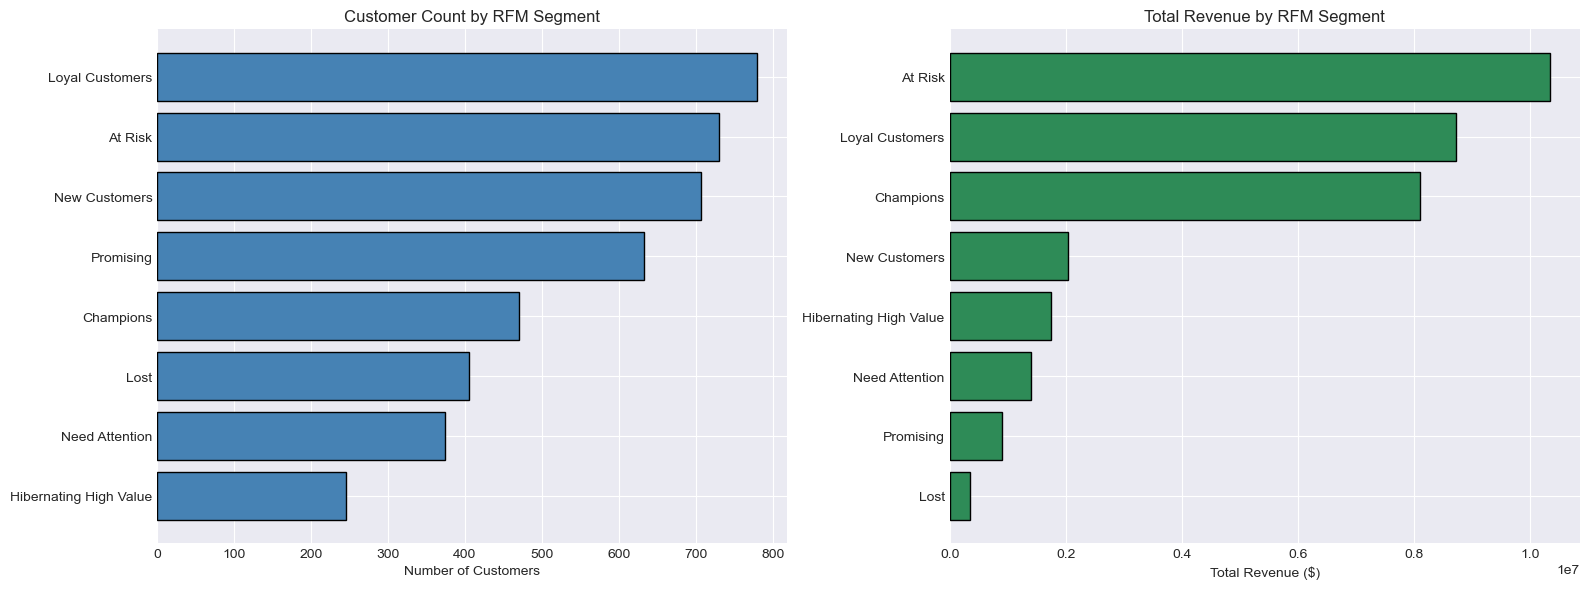

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_counts = rfm_summary['Count'].sort_values(ascending=True)
axes[0].barh(segment_counts.index, segment_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Customer Count by RFM Segment')
axes[0].set_xlabel('Number of Customers')

revenue_by_segment = rfm_summary['Total_Revenue'].sort_values(ascending=True)
axes[1].barh(revenue_by_segment.index, revenue_by_segment.values, color='seagreen', edgecolor='black')
axes[1].set_title('Total Revenue by RFM Segment')
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.savefig('financial_viz/13_rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
customers['cohort_year'] = customers['signup_date'].dt.year

clv_by_segment = customers.groupby('segment').agg({'clv': ['mean', 'median', 'std', 'sum']})
clv_by_segment.columns = ['Mean_CLV', 'Median_CLV', 'Std_CLV', 'Total_CLV']
print("CLV by Customer Segment:\n")
print(clv_by_segment.round(2))

clv_by_cohort = customers.groupby('cohort_year').agg({'clv': ['mean', 'median', 'sum'], 'customer_id': 'count'})
clv_by_cohort.columns = ['Mean_CLV', 'Median_CLV', 'Total_CLV', 'Customer_Count']
print("\nCLV by Signup Year:\n")
print(clv_by_cohort.round(2))

# Payback period: how many months of MRR does it take to earn back the cost of acquiring this customer?
assumed_cac = 500  # Customer Acquisition Cost — a reasonable assumption for a SaaS business at this price point
customers['payback_months'] = assumed_cac / customers['mrr']

print(f"\nCLV Economics:")
print(f"   Assumed CAC: ${assumed_cac}")
print(f"   Average CLV: ${customers['clv'].mean():,.2f}")
print(f"   CLV to CAC Ratio: {customers['clv'].mean() / assumed_cac:.2f}x")
print(f"   Average payback period: {customers['payback_months'].mean():.1f} months")

CLV by Customer Segment:

                Mean_CLV  Median_CLV   Std_CLV    Total_CLV
segment                                                    
Enterprise       7010.63     3212.45   8838.75   3596451.92
Mid-Market       7477.64     2916.00  10696.16   9406869.88
Small Business   7098.99     2826.62   9952.34  14148290.57
Startup          7024.72     2926.60  10213.24   8682557.18

CLV by Signup Year:

             Mean_CLV  Median_CLV    Total_CLV  Customer_Count
cohort_year                                                   
2020         11883.95     7575.17  11325404.43             953
2021         10502.53     6177.30  10313483.58             982
2022          7259.33     4329.84   7484365.41            1031
2023          4780.82     2572.06   4866879.01            1018
2024          1815.00      890.12   1844037.12            1016

CLV Economics:
   Assumed CAC: $500
   Average CLV: $7,166.83
   CLV to CAC Ratio: 14.33x
   Average payback period: 5.0 months


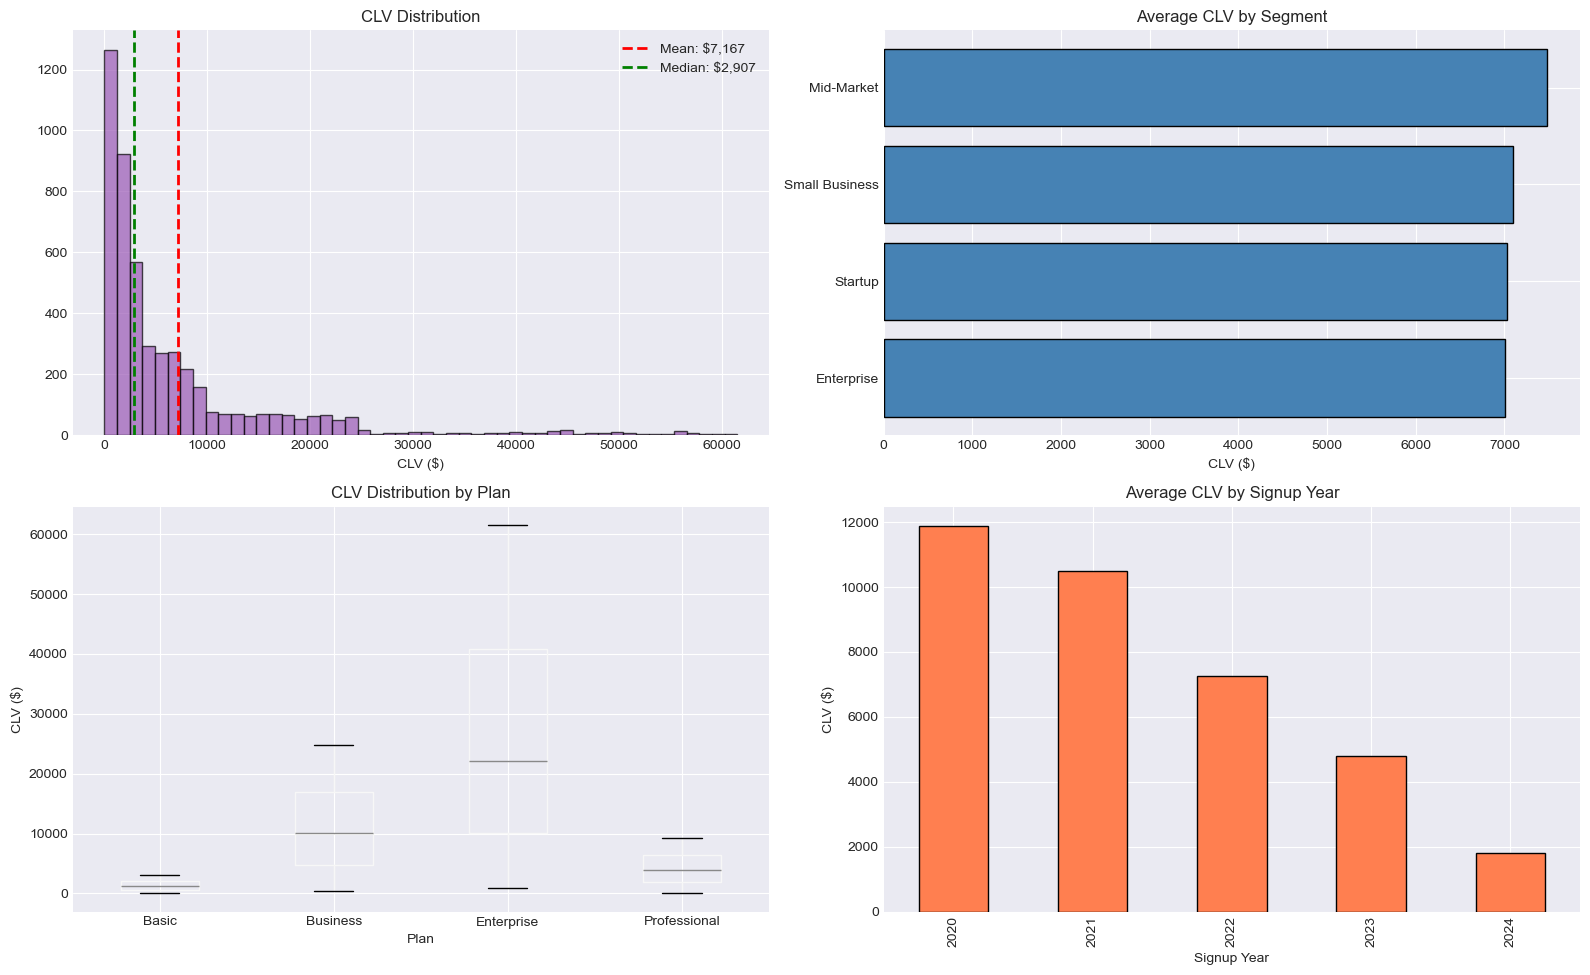

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(customers['clv'], bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
axes[0,0].axvline(customers['clv'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: ${customers['clv'].mean():,.0f}")
axes[0,0].axvline(customers['clv'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: ${customers['clv'].median():,.0f}")
axes[0,0].set_title('CLV Distribution')
axes[0,0].set_xlabel('CLV ($)')
axes[0,0].legend()

clv_segment_mean = customers.groupby('segment')['clv'].mean().sort_values(ascending=True)
axes[0,1].barh(clv_segment_mean.index, clv_segment_mean.values, color='steelblue', edgecolor='black')
axes[0,1].set_title('Average CLV by Segment')
axes[0,1].set_xlabel('CLV ($)')

customers.boxplot(column='clv', by='plan', ax=axes[1,0])
axes[1,0].set_title('CLV Distribution by Plan')
axes[1,0].set_xlabel('Plan')
axes[1,0].set_ylabel('CLV ($)')
plt.suptitle('')  # removes pandas' automatic default title, which clutters this layout

clv_by_cohort['Mean_CLV'].plot(kind='bar', ax=axes[1,1], color='coral', edgecolor='black')
axes[1,1].set_title('Average CLV by Signup Year')
axes[1,1].set_xlabel('Signup Year')
axes[1,1].set_ylabel('CLV ($)')

plt.tight_layout()
plt.savefig('financial_viz/14_clv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# 6.1: Segment profitability
profitability = customers.groupby('segment').agg({
    'customer_id': 'count',
    'mrr': 'sum',
    'total_revenue': ['sum', 'mean'],
    'clv': ['mean', 'sum'],
    'lifetime_months': 'mean',
    'is_churned': ['sum', 'mean']
})
profitability.columns = ['Customer_Count', 'Total_MRR', 'Total_Revenue', 'Avg_Revenue',
                          'Avg_CLV', 'Total_CLV', 'Avg_Lifetime', 'Churned_Count', 'Churn_Rate']
profitability['Churn_Rate'] = profitability['Churn_Rate'] * 100
profitability['Revenue_per_Customer_Month'] = profitability['Total_MRR'] / profitability['Customer_Count']

# Assume a flat 30% cost of service -> 70% gross margin (a simplification; real margins vary by segment)
profitability['Gross_Profit'] = profitability['Total_Revenue'] * 0.7

print("Profitability by Segment:\n")
print(profitability.round(2))
print(f"\nMost Profitable Segment: {profitability['Gross_Profit'].idxmax()}")
print(f"Highest CLV Segment: {profitability['Avg_CLV'].idxmax()}")

# 6.2: Plan mix & pricing
plan_analysis = customers.groupby('plan').agg({
    'customer_id': 'count', 'mrr': ['sum', 'mean'], 'total_revenue': 'sum',
    'clv': 'mean', 'is_churned': 'mean', 'usage_score': 'mean', 'nps_score': 'mean'
})
plan_analysis.columns = ['Customer_Count', 'Total_MRR', 'Avg_MRR', 'Total_Revenue',
                          'Avg_CLV', 'Churn_Rate', 'Avg_Usage', 'Avg_NPS']
plan_analysis['Churn_Rate'] = plan_analysis['Churn_Rate'] * 100
plan_analysis['Revenue_Share_%'] = plan_analysis['Total_Revenue'] / plan_analysis['Total_Revenue'].sum() * 100

print("\nPlan Performance:\n")
print(plan_analysis.round(2))

# 6.3: Geographic profitability
geo_analysis = customers.groupby('country').agg({
    'customer_id': 'count', 'mrr': 'sum', 'total_revenue': 'sum', 'clv': 'mean', 'is_churned': 'mean'
})
geo_analysis.columns = ['Customer_Count', 'Total_MRR', 'Total_Revenue', 'Avg_CLV', 'Churn_Rate']
geo_analysis['Churn_Rate'] = geo_analysis['Churn_Rate'] * 100
geo_analysis = geo_analysis.sort_values('Total_Revenue', ascending=False)

print("\nGeographic Performance:\n")
print(geo_analysis.round(2))

Profitability by Segment:

                Customer_Count  Total_MRR  Total_Revenue  Avg_Revenue  \
segment                                                                 
Enterprise                 513     136487     3596451.92      7010.63   
Mid-Market                1258     336142     9406869.88      7477.64   
Small Business            1993     529507    14148290.57      7098.99   
Startup                   1236     325714     8682557.18      7024.72   

                Avg_CLV    Total_CLV  Avg_Lifetime  Churned_Count  Churn_Rate  \
segment                                                                         
Enterprise      7010.63   3596451.92         27.46           68.0       13.26   
Mid-Market      7477.64   9406869.88         27.53          172.0       13.67   
Small Business  7098.99  14148290.57         26.73          253.0       12.69   
Startup         7024.72   8682557.18         26.48          163.0       13.19   

                Revenue_per_Customer_Month  Gro

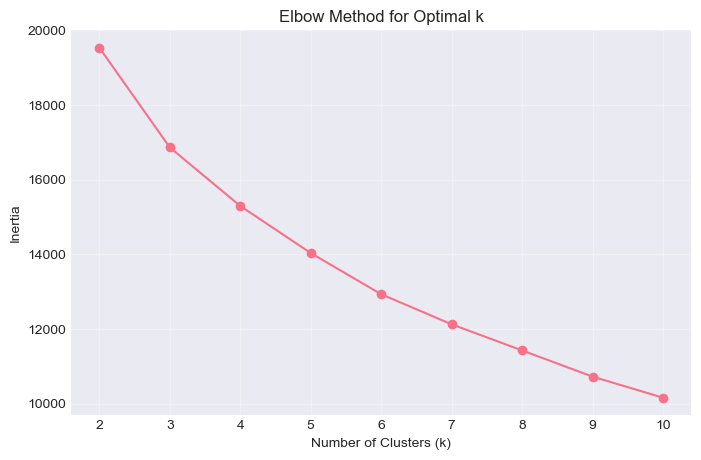

k=2: inertia=19,538.7
k=3: inertia=16,865.4
k=4: inertia=15,297.1
k=5: inertia=14,035.5
k=6: inertia=12,932.1
k=7: inertia=12,125.7
k=8: inertia=11,425.8
k=9: inertia=10,724.4
k=10: inertia=10,159.5


In [46]:
clustering_features = ['mrr', 'lifetime_months', 'usage_score', 'nps_score',
                        'transaction_count', 'support_tickets']

cluster_data = customers[customers['is_churned'] == 0][clustering_features].copy()
cluster_data = cluster_data.fillna(cluster_data.median())

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

# Elbow method: try k from 2 to 10, see where adding more clusters stops helping much
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

for k, inertia in zip(K_range, inertias):
    print(f"k={k}: inertia={inertia:,.1f}")

In [47]:
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_scaled)

customers.loc[customers['is_churned'] == 0, 'ml_cluster'] = cluster_labels

cluster_analysis = customers[customers['is_churned'] == 0].groupby('ml_cluster').agg({
    'customer_id': 'count', 'mrr': ['mean', 'sum'], 'clv': 'mean', 'lifetime_months': 'mean',
    'usage_score': 'mean', 'nps_score': 'mean', 'transaction_count': 'mean', 'support_tickets': 'mean'
})
cluster_analysis.columns = ['Count', 'Avg_MRR', 'Total_MRR', 'Avg_CLV', 'Avg_Lifetime',
                             'Avg_Usage', 'Avg_NPS', 'Avg_Transactions', 'Avg_Tickets']

print(cluster_analysis.round(2))

def name_cluster(row):
    if row['Avg_MRR'] > cluster_analysis['Avg_MRR'].mean() * 1.5:
        return 'Premium Engaged' if row['Avg_Usage'] > cluster_analysis['Avg_Usage'].mean() else 'Premium At-Risk'
    elif row['Avg_Usage'] > cluster_analysis['Avg_Usage'].mean() * 1.2:
        return 'Highly Engaged'
    elif row['Avg_Tickets'] > cluster_analysis['Avg_Tickets'].mean() * 1.5:
        return 'High Support Need'
    else:
        return 'Standard'

cluster_names = cluster_analysis.apply(name_cluster, axis=1)
print("\nCluster Names:")
for i, name in cluster_names.items():
    print(f"   Cluster {int(i)}: {name}")

            Count  Avg_MRR  Total_MRR   Avg_CLV  Avg_Lifetime  Avg_Usage  \
ml_cluster                                                                 
0.0           459   999.00     458541  27826.32         27.31      65.92   
1.0           892   173.10     154408   8087.28         46.07      72.77   
2.0           940   184.85     173760   8303.80         44.19      59.93   
3.0           746   188.81     140854   3203.71         16.49      66.12   
4.0          1307   178.46     233243   2653.18         14.32      65.63   

            Avg_NPS  Avg_Transactions  Avg_Tickets  
ml_cluster                                          
0.0           30.34             27.37         2.09  
1.0           -1.45             45.89         1.85  
2.0           60.00             44.04         1.94  
3.0           27.11             16.73         3.82  
4.0           26.64             14.60         1.13  

Cluster Names:
   Cluster 0: Premium At-Risk
   Cluster 1: Standard
   Cluster 2: Standard
   C

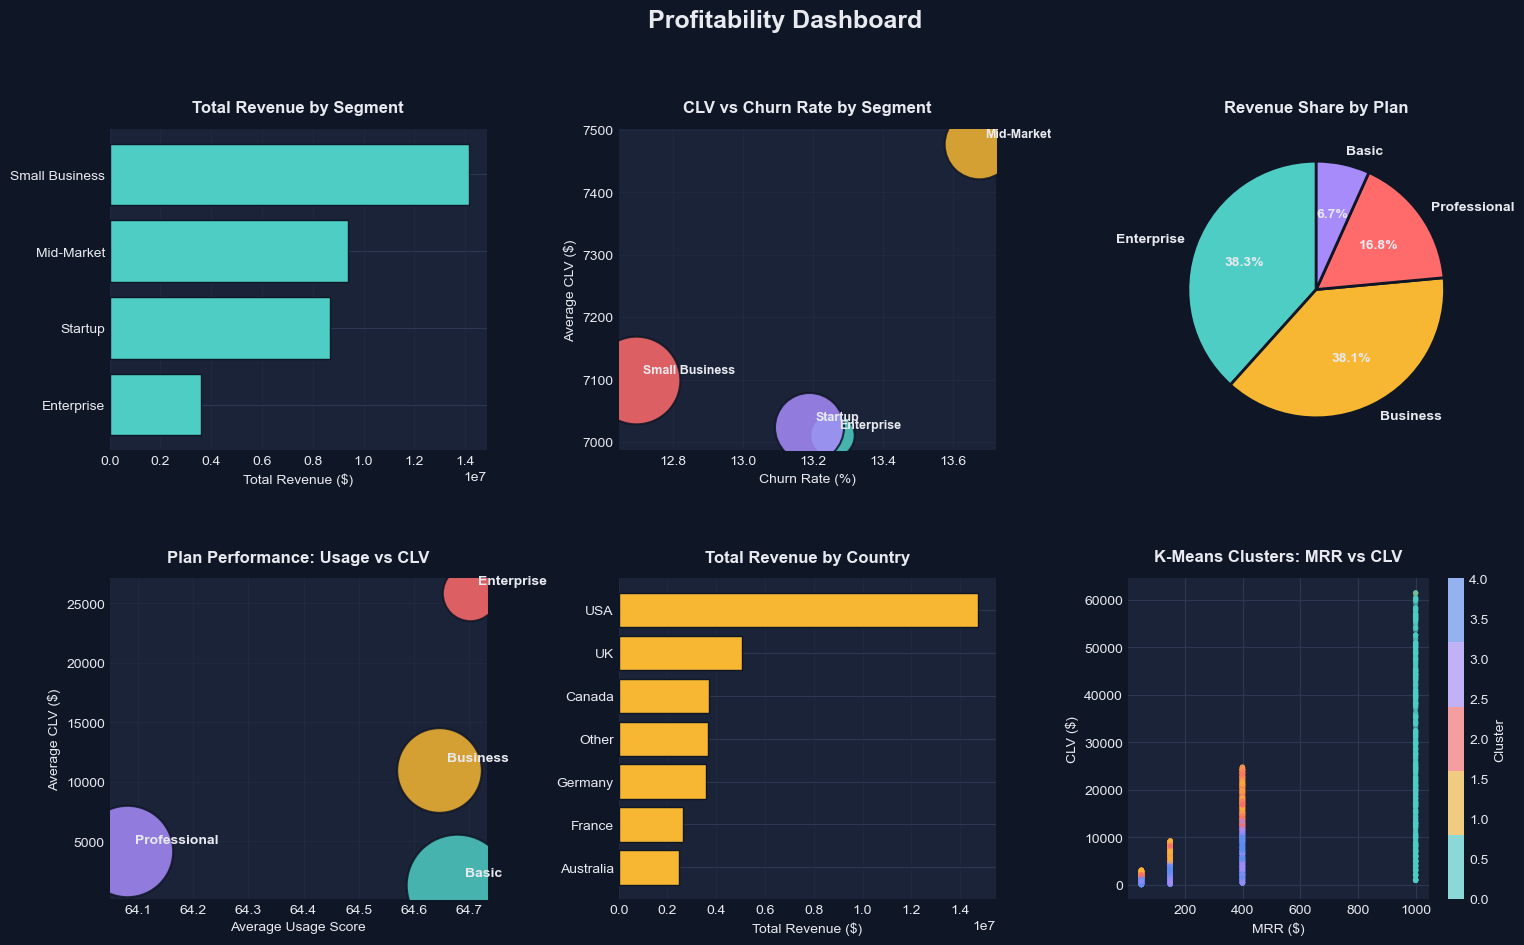

In [50]:
# A small, curated palette instead of matplotlib's defaults
BG_COLOR = '#0F1626'       # deep navy background
PANEL_COLOR = '#1B2338'    # slightly lighter panel background
TEXT_COLOR = '#E8EAF0'     # off-white text
GRID_COLOR = '#2E3752'     # subtle gridlines
ACCENT_TEAL = '#4ECDC4'
ACCENT_GOLD = '#F7B733'
ACCENT_CORAL = '#FF6B6B'
ACCENT_PURPLE = '#A78BFA'
PALETTE = ['#4ECDC4', '#F7B733', '#FF6B6B', '#A78BFA', '#5B8DEF', '#95E06C', '#F45B69']

plt.rcParams.update({
    'text.color': TEXT_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'axes.edgecolor': GRID_COLOR, 'grid.color': GRID_COLOR,
    'font.family': 'sans-serif'
})

fig = plt.figure(figsize=(18, 10), facecolor=BG_COLOR)
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

def style_ax(ax, title):
    ax.set_facecolor(PANEL_COLOR)
    ax.set_title(title, fontweight='bold', fontsize=12, color=TEXT_COLOR, pad=12)
    for spine in ax.spines.values():
        spine.set_color(GRID_COLOR)
    ax.tick_params(colors=TEXT_COLOR)

# 1. Revenue by segment
ax1 = fig.add_subplot(gs[0, 0])
profitability_sorted = profitability.sort_values('Total_Revenue', ascending=True)
ax1.barh(profitability_sorted.index, profitability_sorted['Total_Revenue'], color=ACCENT_TEAL, edgecolor=BG_COLOR)
style_ax(ax1, 'Total Revenue by Segment')
ax1.set_xlabel('Total Revenue ($)')
ax1.grid(axis='x', alpha=0.25)

# 2. CLV vs Churn Rate by segment
ax2 = fig.add_subplot(gs[0, 1])
for i, segment in enumerate(profitability.index):
    clv = profitability.loc[segment, 'Avg_CLV']
    churn = profitability.loc[segment, 'Churn_Rate']
    count = profitability.loc[segment, 'Customer_Count']
    ax2.scatter(churn, clv, s=count*2, alpha=0.85, color=PALETTE[i % len(PALETTE)],
                edgecolors=BG_COLOR, linewidth=1.5)
    ax2.annotate(segment, (churn, clv), fontsize=9, fontweight='bold', color=TEXT_COLOR,
                 xytext=(5, 5), textcoords='offset points')
style_ax(ax2, 'CLV vs Churn Rate by Segment')
ax2.set_xlabel('Churn Rate (%)')
ax2.set_ylabel('Average CLV ($)')
ax2.grid(True, alpha=0.25)

# 3. Revenue share by plan
ax3 = fig.add_subplot(gs[0, 2])
plan_revenue_share = plan_analysis['Revenue_Share_%'].sort_values(ascending=False)
wedges, texts, autotexts = ax3.pie(
    plan_revenue_share.values, labels=plan_revenue_share.index, autopct='%1.1f%%',
    startangle=90, colors=PALETTE, wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 2},
    textprops={'color': TEXT_COLOR, 'fontweight': 'bold'}
)
ax3.set_facecolor(PANEL_COLOR)
ax3.set_title('Revenue Share by Plan', fontweight='bold', fontsize=12, color=TEXT_COLOR, pad=12)

# 4. Plan performance: usage vs CLV
ax4 = fig.add_subplot(gs[1, 0])
for i, plan in enumerate(plan_analysis.index):
    x = plan_analysis.loc[plan, 'Avg_Usage']
    y = plan_analysis.loc[plan, 'Avg_CLV']
    count = plan_analysis.loc[plan, 'Customer_Count']
    ax4.scatter(x, y, s=count*3, alpha=0.85, color=PALETTE[i % len(PALETTE)], edgecolors=BG_COLOR, linewidth=1.5)
    ax4.annotate(plan, (x, y), fontsize=10, fontweight='bold', color=TEXT_COLOR,
                 xytext=(6, 6), textcoords='offset points')
style_ax(ax4, 'Plan Performance: Usage vs CLV')
ax4.set_xlabel('Average Usage Score')
ax4.set_ylabel('Average CLV ($)')
ax4.grid(True, alpha=0.25)

# 5. Geographic revenue
ax5 = fig.add_subplot(gs[1, 1])
geo_sorted = geo_analysis.sort_values('Total_Revenue', ascending=True)
ax5.barh(geo_sorted.index, geo_sorted['Total_Revenue'], color=ACCENT_GOLD, edgecolor=BG_COLOR)
style_ax(ax5, 'Total Revenue by Country')
ax5.set_xlabel('Total Revenue ($)')
ax5.grid(axis='x', alpha=0.25)

# 6. K-Means clusters: MRR vs CLV
ax6 = fig.add_subplot(gs[1, 2])
clustered = customers[customers['is_churned'] == 0]
from matplotlib.colors import ListedColormap
cluster_cmap = ListedColormap(PALETTE[:5])
scatter = ax6.scatter(clustered['mrr'], clustered['clv'], c=clustered['ml_cluster'],
                       cmap=cluster_cmap, alpha=0.6, s=15, edgecolors='none')
style_ax(ax6, 'K-Means Clusters: MRR vs CLV')
ax6.set_xlabel('MRR ($)')
ax6.set_ylabel('CLV ($)')
cbar = plt.colorbar(scatter, ax=ax6, label='Cluster')
cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
cbar.outline.set_edgecolor(GRID_COLOR)
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color=TEXT_COLOR)
cbar.set_label('Cluster', color=TEXT_COLOR)

fig.suptitle('Profitability Dashboard', fontsize=18, fontweight='bold', color=TEXT_COLOR, y=1.0)
plt.tight_layout()
plt.savefig('financial_viz/15_profitability_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [51]:
total_customers_current = len(customers)
active_customers_current = (customers['is_churned'] == 0).sum()
total_mrr_current = customers[customers['is_churned'] == 0]['mrr'].sum()
total_arr = total_mrr_current * 12
avg_revenue_per_account = customers['total_revenue'].mean()
total_revenue_all_time = transactions['amount'].sum()

avg_clv_current = customers['clv'].mean()
median_clv_current = customers['clv'].median()
churn_rate_current = (customers['is_churned'].sum() / len(customers)) * 100

at_risk_mrr = at_risk_output['mrr'].sum()

kpi_summary = f"""
KEY PERFORMANCE INDICATORS

REVENUE METRICS
  - Total All-Time Revenue         : ${total_revenue_all_time:,.2f}
  - Current Monthly MRR            : ${total_mrr_current:,.2f}
  - Annual Recurring Revenue (ARR) : ${total_arr:,.2f}
  - Average Revenue per Account    : ${avg_revenue_per_account:,.2f}
  - Revenue Growth Rate (6mo)      : {revenue_growth_rate:+.2f}%

CUSTOMER METRICS
  - Total Customers                : {total_customers_current:,}
  - Active Customers               : {active_customers_current:,}
  - Churned Customers              : {total_customers_current - active_customers_current:,}
  - Overall Churn Rate             : {churn_rate_current:.2f}%
  - Average Customer Lifetime      : {customers['lifetime_months'].mean():.1f} months

CUSTOMER VALUE
  - Average CLV                    : ${avg_clv_current:,.2f}
  - Median CLV                     : ${median_clv_current:,.2f}
  - CLV to CAC Ratio               : {avg_clv_current / 500:.2f}x (assumed CAC: $500)
  - Average Payback Period         : {customers['payback_months'].mean():.1f} months

FORECASTING
  - Forecasted Revenue (Next 12mo) : ${forecast_mean.sum():,.2f}
  - Expected Monthly Average       : ${forecast_mean.mean():,.2f}
  - Model Accuracy (MAPE)          : {mape:.2f}%

RISK METRICS
  - At-Risk Customers (active, >15% churn prob) : {len(at_risk_output):,}
  - At-Risk MRR                    : ${at_risk_mrr:,.2f}
  - Potential Annual Revenue Loss  : ${at_risk_mrr * 12:,.2f}
"""

print(kpi_summary)

with open('kpi_summary.txt', 'w') as f:
    f.write(kpi_summary)
print("Saved KPI summary to: 'kpi_summary.txt'")


KEY PERFORMANCE INDICATORS

REVENUE METRICS
  - Total All-Time Revenue         : $35,834,169.55
  - Current Monthly MRR            : $1,160,806.00
  - Annual Recurring Revenue (ARR) : $13,929,672.00
  - Average Revenue per Account    : $7,166.83
  - Revenue Growth Rate (6mo)      : +13.26%

CUSTOMER METRICS
  - Total Customers                : 5,000
  - Active Customers               : 4,344
  - Churned Customers              : 656
  - Overall Churn Rate             : 13.12%
  - Average Customer Lifetime      : 26.9 months

CUSTOMER VALUE
  - Average CLV                    : $7,166.83
  - Median CLV                     : $2,907.19
  - CLV to CAC Ratio               : 14.33x (assumed CAC: $500)
  - Average Payback Period         : 5.0 months

FORECASTING
  - Forecasted Revenue (Next 12mo) : $15,695,315.57
  - Expected Monthly Average       : $1,307,942.96
  - Model Accuracy (MAPE)          : 0.77%

RISK METRICS
  - At-Risk Customers (active, >15% churn prob) : 1,166
  - At-Risk MRR    

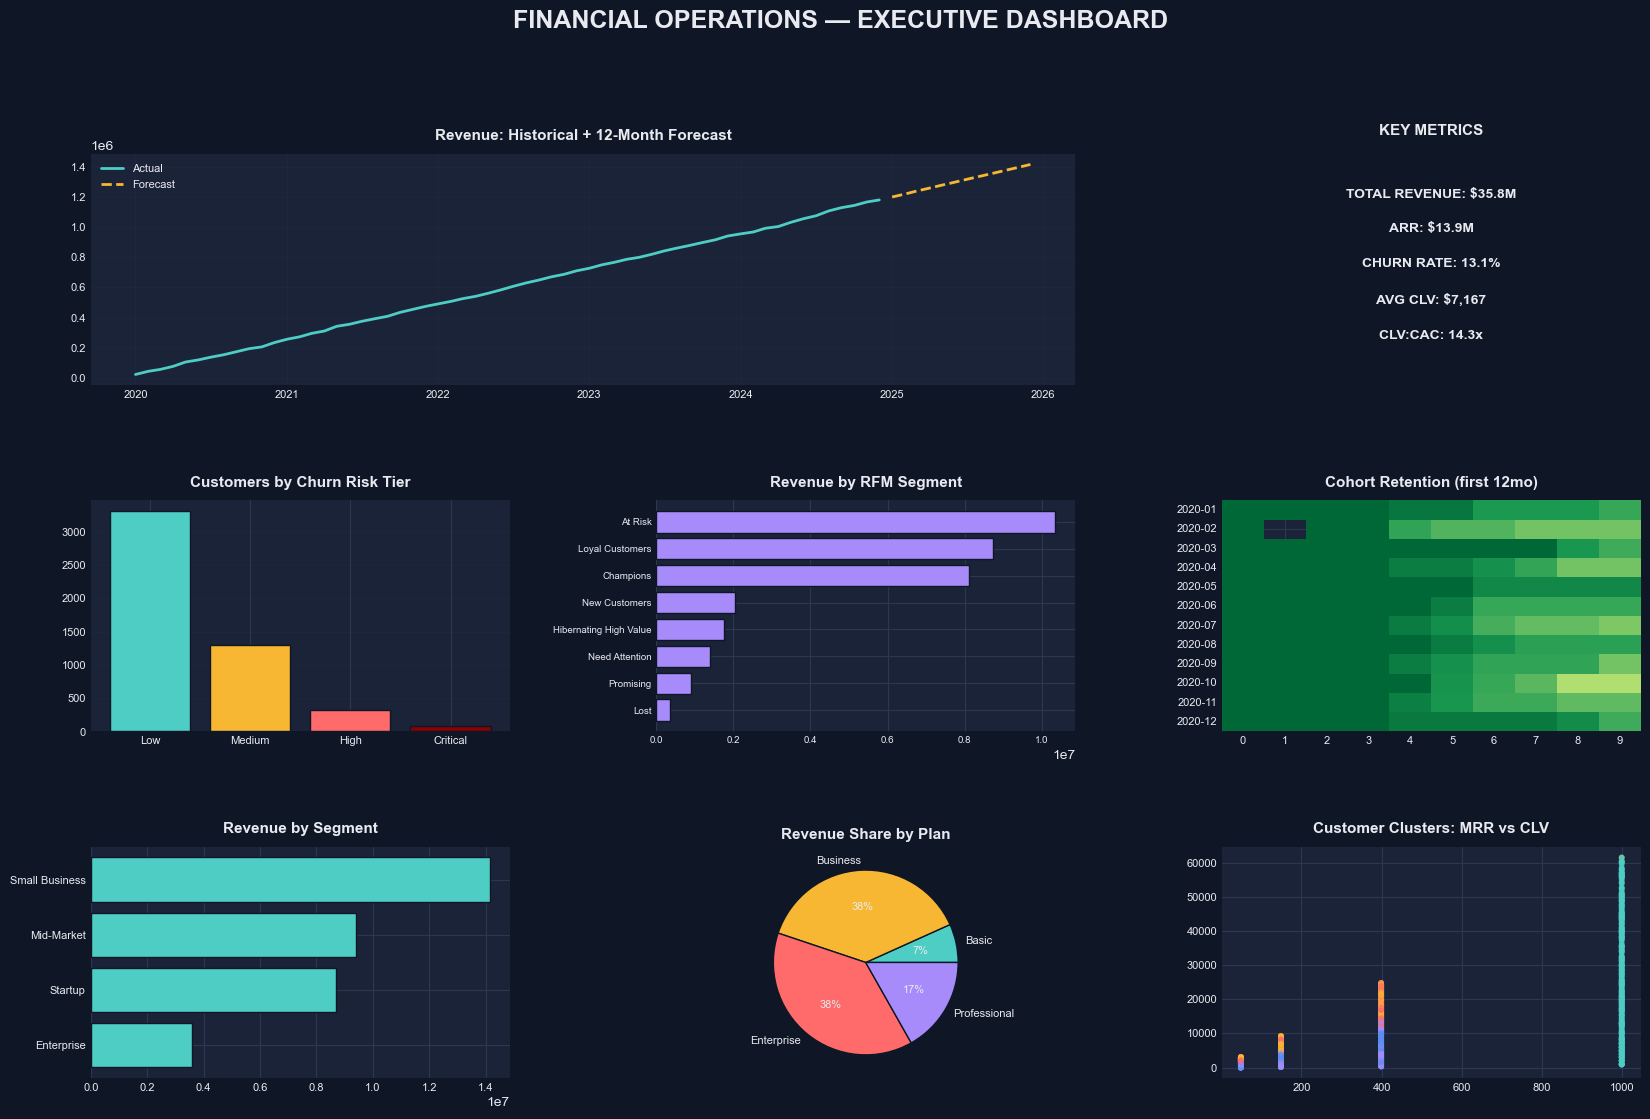

In [54]:
fig = plt.figure(figsize=(20, 12), facecolor=BG_COLOR)
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.35)

def style_ax(ax, title):
    ax.set_facecolor(PANEL_COLOR)
    ax.set_title(title, fontweight='bold', fontsize=11, color=TEXT_COLOR, pad=10)
    for spine in ax.spines.values():
        spine.set_color(GRID_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8)

# 1. Revenue trend + forecast
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(revenue_series.index, revenue_series.values, color=ACCENT_TEAL, linewidth=2, label='Actual')
ax1.plot(forecast_mean.index, forecast_mean.values, color=ACCENT_GOLD, linewidth=2, linestyle='--', label='Forecast')
style_ax(ax1, 'Revenue: Historical + 12-Month Forecast')
ax1.legend(facecolor=PANEL_COLOR, labelcolor=TEXT_COLOR, fontsize=8)
ax1.grid(alpha=0.2)

# 2. KPI text panel
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
ax2.set_facecolor(PANEL_COLOR)
kpi_text = (
    f"TOTAL REVENUE: ${total_revenue_all_time/1e6:.1f}M\n\n"
    f"ARR: ${total_arr/1e6:.1f}M\n\n"
    f"CHURN RATE: {churn_rate_current:.1f}%\n\n"
    f"AVG CLV: ${avg_clv_current:,.0f}\n\n"
    f"CLV:CAC: {avg_clv_current/500:.1f}x"
)
ax2.text(0.5, 0.85, kpi_text, ha='center', va='top', fontsize=10, fontweight='bold',
         color=TEXT_COLOR, transform=ax2.transAxes, linespacing=1.6)
ax2.set_title('KEY METRICS', fontweight='bold', fontsize=11, color=TEXT_COLOR, pad=14)

# 3. Churn risk tiers
ax3 = fig.add_subplot(gs[1, 0])
tier_counts = churn_model_data['churn_risk_tier'].value_counts().reindex(['Low','Medium','High','Critical'])
ax3.bar(tier_counts.index, tier_counts.values, color=[ACCENT_TEAL, ACCENT_GOLD, ACCENT_CORAL, '#8B0000'], edgecolor=BG_COLOR)
style_ax(ax3, 'Customers by Churn Risk Tier')
ax3.grid(axis='y', alpha=0.2)

# 4. RFM segment revenue
ax4 = fig.add_subplot(gs[1, 1])
rfm_rev_sorted = rfm_summary['Total_Revenue'].sort_values(ascending=True)
ax4.barh(rfm_rev_sorted.index, rfm_rev_sorted.values, color=ACCENT_PURPLE, edgecolor=BG_COLOR)
style_ax(ax4, 'Revenue by RFM Segment')
ax4.tick_params(labelsize=7)

# 5. Retention heatmap (small)
ax5 = fig.add_subplot(gs[1, 2])
sns.heatmap(retention_pct.iloc[:12, :10], cmap='RdYlGn', vmin=70, vmax=100, cbar=False, ax=ax5)
style_ax(ax5, 'Cohort Retention (first 12mo)')
ax5.set_xlabel('')
ax5.set_ylabel('')

# 6. Revenue by segment
ax6 = fig.add_subplot(gs[2, 0])
seg_rev = profitability['Total_Revenue'].sort_values(ascending=True)
ax6.barh(seg_rev.index, seg_rev.values, color=ACCENT_TEAL, edgecolor=BG_COLOR)
style_ax(ax6, 'Revenue by Segment')

# 7. Plan revenue share
ax7 = fig.add_subplot(gs[2, 1])
ax7.pie(plan_analysis['Revenue_Share_%'], labels=plan_analysis.index, autopct='%1.0f%%',
        colors=PALETTE, textprops={'color': TEXT_COLOR, 'fontsize': 8},
        wedgeprops={'edgecolor': BG_COLOR})
ax7.set_facecolor(PANEL_COLOR)
ax7.set_title('Revenue Share by Plan', fontweight='bold', fontsize=11, color=TEXT_COLOR)

# 8. K-Means clusters
ax8 = fig.add_subplot(gs[2, 2])
clustered = customers[customers['is_churned'] == 0]
from matplotlib.colors import ListedColormap
scatter = ax8.scatter(clustered['mrr'], clustered['clv'], c=clustered['ml_cluster'],
                       cmap=ListedColormap(PALETTE[:5]), alpha=0.6, s=10)
style_ax(ax8, 'Customer Clusters: MRR vs CLV')

fig.suptitle('FINANCIAL OPERATIONS — EXECUTIVE DASHBOARD', fontsize=18, fontweight='bold', color=TEXT_COLOR, y=1.0)
plt.tight_layout()
plt.savefig('financial_viz/16_FINAL_EXECUTIVE_DASHBOARD.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [55]:
# Forecast export: actual history + both models' 12-month forecasts, on one aligned timeline
forecast_export = pd.DataFrame({
    'month': pd.date_range('2025-01-01', periods=12, freq='MS'),
    'arima_forecast': forecast_mean.values,
    'prophet_forecast': prophet_forecast['yhat'].tail(12).values
})
forecast_export.to_csv('forecast_export.csv', index=False)

# Add ml_cluster onto a clean customer export for Power BI
customers_export = customers.copy()
customers_export['churn_probability'] = churn_model_data['churn_probability']
customers_export['churn_risk_tier'] = churn_model_data['churn_risk_tier']
customers_export.to_csv('customers_for_powerbi.csv', index=False)

print("Saved: forecast_export.csv")
print("Saved: customers_for_powerbi.csv")
print(f"\nforecast_export shape: {forecast_export.shape}")
print(f"customers_export shape: {customers_export.shape}")
print(customers_export[['customer_id','ml_cluster','churn_probability','churn_risk_tier']].head())

Saved: forecast_export.csv
Saved: customers_for_powerbi.csv

forecast_export shape: (12, 3)
customers_export shape: (5000, 27)
   customer_id  ml_cluster  churn_probability churn_risk_tier
0  CUST_000001         4.0           0.162499          Medium
1  CUST_000002         4.0           0.216310          Medium
2  CUST_000003         NaN           0.158349          Medium
3  CUST_000004         3.0           0.169985          Medium
4  CUST_000005         4.0           0.321558            High


In [56]:
import os
print("Your files are saved in this folder:")
print(os.getcwd())

Your files are saved in this folder:
C:\Users\ASUS\Financial_Opearations_Analytics
